# Fixed-Point Quantization Testbed

This notebook evaluates model performance under different fixed-point quantization bit-widths.

**Key Metrics:**
- ROC curves
- AUC (Area Under Curve)
- TPR at FPR = 1e-5

**Quantization formats tested:**
- Float32 (baseline)
- Various fixed-point: Q<I>.<F> where I=integer bits, F=fractional bits

In [16]:
# Imports
import os
import sys
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from sklearn.metrics import auc
import pandas as pd

# Set up paths
sys.path.insert(0, os.path.abspath('..'))

from cascaded_tn.quantization import QuantizationTestbed
from cascaded_tn.training.cascaded_model import CascadedModel, create_trainable_autoencoder
from tn4ml.embeddings import embed, TrigonometricEmbedding, ParticleVectorEmbedding
from tn4ml.eval import get_roc_curve_data
from tn4ml.metrics import TransformedNorm

import quimb.tensor as qtn

# Configure JAX
jax.config.update("jax_enable_x64", False)
jax.config.update('jax_default_matmul_precision', 'float32')

print("✅ Imports successful")

✅ Imports successful


## 1. Load or Create Model

In [17]:
# Load trained model
model_dir = '../models_to_share/fromPrajita/cascade_noReLU'
# model_dir = '../output/Reorder_Compress_19_1_bd4_hub20'
model_name = 'final_best_model.pkl'
model_path = model_dir + '/' + model_name
autoencoder = CascadedModel.load(model_path)
print(f"✅ Loaded trained model from {model_path}")
print(f"   Parameters: {autoencoder.nparams():,}")

print(f"✅ Model ready")
print(f"   Architecture: {[op.config.input_dim for op in autoencoder.cascade.operators]} → {autoencoder.cascade.operators[-1].config.output_dim}")
print(f"   Parameters: {autoencoder.nparams():,}")
autoencoder.summary()

[LOADING] Model from ../models_to_share/fromPrajita/cascade_noReLU/final_best_model.pkl
  - 4,482 parameters
  - 2 layers
[LOADED] Successfully loaded model
✅ Loaded trained model from ../models_to_share/fromPrajita/cascade_noReLU/final_best_model.pkl
   Parameters: 4,482
✅ Model ready
   Architecture: [19, 7] → 3
   Parameters: 4,482

CASCADED MODEL SUMMARY

CASCADE SUMMARY: OpenAutoencoder_19to3
Architecture: 19 → 7 → 3

Layers: 2
  0: Unified↓(19→7, χ=8)
  1: Unified↓(7→3, χ=3) (bottleneck)


Training Configuration:
  Strategy: global
  Optimizer: <function adam at 0x7fc107091f80>
  Learning rate: 0.01
  Loss function: None
  Training type: 0

Total parameters: 4,482

Parameters by layer:
  Layer 0 (Unified↓(19→7, χ=8)): 4,320 parameters
  Layer 1 (Unified↓(7→3, χ=3)): 162 parameters



In [18]:
import numpy as np
import jax

def export_cascade_weights(autoencoder, output_path, layer_sites):
    """
    Export cascade weights to C++ header.
    
    Args:
        autoencoder: Trained CascadedModel
        output_path: Path to write weights.h
        layer_sites: List of sites per layer, e.g., [19, 7] for 19->7->3
    """
    
    def extract_layer(start_idx, num_sites):
        """Extract one SMPO layer starting at start_idx."""
        # Detect dimensions from all tensors
        all_tensors = [np.array(jax.device_get(autoencoder.arrays[start_idx + i])) 
                    for i in range(num_sites)]
        
        # Find max bond and phys dimensions
        max_bond = 1
        phys_in = all_tensors[0].shape[-2] if len(all_tensors[0].shape) >= 2 else all_tensors[0].shape[-1]
        phys_out = 1
        
        for tensor in all_tensors:
            if len(tensor.shape) >= 3:
                max_bond = max(max_bond, tensor.shape[0])
            if len(tensor.shape) == 4:
                max_bond = max(max_bond, tensor.shape[1])
                phys_in = tensor.shape[-2]
                phys_out = tensor.shape[-1]
        
        # Create dense array
        weights = np.zeros((num_sites, phys_in, phys_out, max_bond, max_bond), 
                        dtype=np.float32)
        
        # Fill based on actual tensor shape
        for site_idx in range(num_sites):
            tensor = all_tensors[site_idx]
            shape = tensor.shape
            
            if len(shape) == 4:  # Interior with output: (L, R, pin, pout)
                weights[site_idx, :, :, :, :] = np.transpose(tensor, (2, 3, 0, 1))
            elif len(shape) == 3:
                # Could be edge with output OR interior without output
                if shape[0] == shape[1]:  # Interior without output: (L, R, pin)
                    transposed = np.transpose(tensor, (2, 0, 1))
                    weights[site_idx, :, 0, :, :] = transposed
                else:  # Edge with output: (bond, pin, pout)
                    transposed = np.transpose(tensor, (1, 2, 0))
                    if site_idx == 0:
                        weights[site_idx, :, :, 0, :] = transposed
                    else:  # site_idx == num_sites - 1
                        weights[site_idx, :, :, :, 0] = transposed
            elif len(shape) == 2:  # Edge without output: (bond, pin)
                if site_idx == 0:  # Left edge
                    weights[site_idx, :, 0, 0, :] = tensor.T
                else:  # Right edge
                    weights[site_idx, :, 0, :, 0] = tensor.T
        
        return weights
    
    # Extract all layers
    layers = []
    tensor_idx = 0
    for num_sites in layer_sites:
        layer_weights = extract_layer(tensor_idx, num_sites)
        layers.append(layer_weights)
        print(f"Layer {len(layers)}: {np.count_nonzero(layer_weights)} non-zero elements")
        tensor_idx += num_sites
    
    # Write C++ header
    write_cpp_header(layers, output_path)
    print(f"Wrote weights to {output_path}")


def write_cpp_header(layers, output_path):
    """Write arbitrary number of layers to C++ header."""
    with open(output_path, 'w') as f:
        f.write("// Auto-generated weights file\n")
        f.write("// DO NOT EDIT MANUALLY\n\n")
        f.write("#ifndef WEIGHTS_H\n")
        f.write("#define WEIGHTS_H\n\n")
        f.write('#include "defines.h"\n\n')
        
        for layer_num, weights in enumerate(layers, 1):
            sites, phys_in, phys_out, left_bond, right_bond = weights.shape
            
            f.write(f"// Layer {layer_num} weights: [{sites}][{phys_in}][{phys_out}]"
                   f"[{left_bond}][{right_bond}]\n")
            f.write(f"const data_t weights{layer_num}_data[{sites}][{phys_in}]"
                   f"[{phys_out}][{left_bond}][{right_bond}] = {{\n")
            
            for i in range(sites):
                f.write("  { // Site %d\n" % i)
                for pin in range(phys_in):
                    f.write("    { // phys_in=%d\n" % pin)
                    for pout in range(phys_out):
                        f.write("      { // phys_out=%d\n" % pout)
                        for l in range(left_bond):
                            f.write("        {")
                            for r in range(right_bond):
                                f.write("%.16ff" % weights[i, pin, pout, l, r])
                                if r < right_bond - 1:
                                    f.write(", ")
                            f.write("}")
                            if l < left_bond - 1:
                                f.write(",\n")
                            else:
                                f.write("\n")
                        f.write("      }")
                        if pout < phys_out - 1:
                            f.write(",\n")
                        else:
                            f.write("\n")
                    f.write("    }")
                    if pin < phys_in - 1:
                        f.write(",\n")
                    else:
                        f.write("\n")
                f.write("  }")
                if i < sites - 1:
                    f.write(",\n")
                else:
                    f.write("\n")
            
            f.write("};\n\n")
        
        f.write("#endif // WEIGHTS_H\n")

In [19]:
export_cascade_weights(autoencoder, "../TN_HLS/test-weights.h", layer_sites=[19,7])

Layer 1: 4320 non-zero elements
Layer 2: 162 non-zero elements
Wrote weights to ../TN_HLS/test-weights.h


## 2. Set Up Embedding and Metric Function

In [3]:
# Set up embedding (use the same one from training)
embedding = ParticleVectorEmbedding(normalize=False)

# Define target loss (adjust based on your training)
target_loss = 50.0

# Define the anomaly score function)
def InputsToNorm(model, data):
    """Norm itself"""
    x = TransformedNorm(model, data)
    return x


# Define the anomaly score function)
def InputsToScore(model, data):
    """Anomaly score based on deviation from target norm."""
    x = TransformedNorm(model, data)
    return jax.lax.abs(x - target_loss)

@jax.jit
def ComputeNorm(data, targets, *params):
    """Compute the norm."""
    temp_model = autoencoder.copy()
    for tensor, param in zip(temp_model.tensors, params):
        tensor.modify(data=param)
    
    tn_i = embed(data, embedding)
    
    return InputsToNorm(temp_model, tn_i)


@jax.jit
def ComputeScore(data, targets, *params):
    """Compute the anomaly score."""
    temp_model = autoencoder.copy()
    for tensor, param in zip(temp_model.tensors, params):
        tensor.modify(data=param)
    
    tn_i = embed(data, embedding)
    
    return InputsToScore(temp_model, tn_i)

# Vectorize for batch processing
norm_term = jax.jit(jax.vmap(ComputeNorm, in_axes=[0, None] + [None]*autoencoder.L), backend='gpu')
score_term = jax.jit(jax.vmap(ComputeScore, in_axes=[0, None] + [None]*autoencoder.L), backend='gpu')

print("✅ Metric function ready")

✅ Metric function ready


## 3. Create Data Loaders

In [4]:
# Schedule data loading
import utils.dataloader as d
inputPath = "/lus/eagle/projects/ATLAS_workflow_ALCF/sagar/QiML/"
background_loader = d.load_data(inputPath + "background_for_training.h5", batch_size=10000, shuffle=False, skip_MET_eta=False, norm=True)
signal_loaders = {
    'Ato4l': d.load_data(inputPath + "Ato4l_lepFilter_13TeV.h5", batch_size=10000, shuffle=False, skip_MET_eta=False, norm=True),
    'LQ': d.load_data(inputPath + "leptoquark_LOWMASS_lepFilter_13TeV.h5", batch_size=10000, shuffle=False, skip_MET_eta=False, norm=True),
    'hToTauNu': d.load_data(inputPath + "hChToTauNu_13TeV_PU20.h5", batch_size=10000, shuffle=False, skip_MET_eta=False, norm=True),
    'hToTauTau': d.load_data(inputPath + "hToTauTau_13TeV_PU20.h5", batch_size=10000, shuffle=False, skip_MET_eta=False, norm=True),
}

In [ ]:
# Schedule data loading
import utils.dataloader as d
inputPath = "/lus/eagle/projects/ATLAS_workflow_ALCF/sagar/QiML/"
batch_size = 10000
background, background_val, background_test = d.create_split_dataloaders(
    file_path=inputPath+"background_for_training.h5",
    batch_size=batch_size,
    split_ratios=(0.70, 0.05, 0.25),
    norm=True,
    skip_MET_eta=False,
    shuffle=False,
)

[DATASET SPLITS]
  Total samples: 4,000,000
  Train: 2,800,000 (70.0%)
  Val:   200,000 (5.0%)
  Test:  1,000,000 (25.0%)

[DATALOADERS CREATED]
  Train batches: 684
  Val batches:   49
  Test batches:  245


In [6]:
test_event = next(iter(background_loader))[0]
test_event_np = np.array(test_event)

/tmp/ipykernel_1951375/2039357933.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  test_event_np = np.array(test_event)


In [7]:
print(test_event_np)
input_mps = embed(test_event, embedding)

[0.01180661 0.5        0.63983221 0.         0.5        0.5
 0.         0.5        0.5        0.         0.5        0.5
 0.         0.5        0.5        0.06876636 0.30485379 0.33162889
 0.         0.5        0.5        0.         0.5        0.5
 0.         0.5        0.5        0.01586162 0.22172623 0.75593168
 0.         0.5        0.5        0.         0.5        0.5
 0.         0.5        0.5        0.         0.5        0.5
 0.         0.5        0.5        0.         0.5        0.5
 0.         0.5        0.5        0.         0.5        0.5
 0.         0.5        0.5       ]


In [8]:
total_norm = 1.
for site in range(int(len(test_event_np)/3)):
   norm_site = 0
   for index in range(3):
      norm_site += test_event_np[3*site+index]*test_event_np[3*site+index]
   print("norm of this site ", site, " is ", norm_site)
   total_norm *= norm_site
print("total norm is ", total_norm**.5)

norm of this site  0  is  0.6595246588424236
norm of this site  1  is  0.5
norm of this site  2  is  0.5
norm of this site  3  is  0.5
norm of this site  4  is  0.5
norm of this site  5  is  0.20764236453106028
norm of this site  6  is  0.5
norm of this site  7  is  0.5
norm of this site  8  is  0.5
norm of this site  9  is  0.6208468225286596
norm of this site  10  is  0.5
norm of this site  11  is  0.5
norm of this site  12  is  0.5
norm of this site  13  is  0.5
norm of this site  14  is  0.5
norm of this site  15  is  0.5
norm of this site  16  is  0.5
norm of this site  17  is  0.5
norm of this site  18  is  0.5
total norm is  0.001139005360288573


In [9]:
mps_1 = autoencoder.cascade[0].apply(input_mps)

In [10]:
# Basic structure info
print(f"MPS has {mps_1.L} sites")
print(f"Site tag ID: {mps_1.site_tag_id}")
print(f"Site ind ID: {mps_1.site_ind_id}")

# Per-tensor details
for i, tensor in enumerate(mps_1.tensors):
    print(f"\nSite {i}:")
    print(f"  Shape: {tensor.shape}")
    print(f"  Indices: {tensor.inds}")
    print(f"  Tags: {tensor.tags}")
    print(f"  Num elements: {tensor.data.size}")
    
    # Print actual values (first few)
    data_flat = tensor.data.flatten()
    print(f"  First 5 values: {data_flat[:5]}")
    print(f"  Min/Max: {tensor.data.min():.6f} / {tensor.data.max():.6f}")
    print(f"  Norm (Frobenius): {jnp.linalg.norm(tensor.data):.6f}")
    
    # If you want ALL values (careful with large tensors):
    # print(f"  All values:\n{tensor.data}")

MPS has 7 sites
Site tag ID: I{}
Site ind ID: k{}

Site 0:
  Shape: (8, 2)
  Indices: ('_191fafAAAAs', 'k0')
  Tags: oset(['I0'])
  Num elements: 16
  First 5 values: [2.0849495  1.4240851  0.0293552  0.14908898 0.04386036]
  Min/Max: -0.161709 / 2.084949


  Norm (Frobenius): 2.641108

Site 1:
  Shape: (8, 8, 2)
  Indices: ('_191fafAAAAs', '_191fafAAAAt', 'k1')
  Tags: oset(['I1'])
  Num elements: 128
  First 5 values: [0.2743479  0.27480236 0.08147787 0.16939208 0.11941686]
  Min/Max: -1.060706 / 1.500390
  Norm (Frobenius): 4.122400

Site 2:
  Shape: (8, 8, 2)
  Indices: ('_191fafAAAAt', '_191fafAAAAu', 'k2')
  Tags: oset(['I2'])
  Num elements: 128
  First 5 values: [ 0.14090055 -0.1425077  -0.08009233  0.08706673  0.01714997]
  Min/Max: -0.310360 / 0.409781
  Norm (Frobenius): 1.597586

Site 3:
  Shape: (8, 8, 2)
  Indices: ('_191fafAAAAu', '_191fafAAAAv', 'k3')
  Tags: oset(['I3'])
  Num elements: 128
  First 5 values: [ 0.33948687 -0.08916511  0.09649318  0.1609729   0.19063616]
  Min/Max: -0.693727 / 1.013363
  Norm (Frobenius): 3.313267

Site 4:
  Shape: (8, 8, 2)
  Indices: ('_191fafAAAAv', '_191fafAAAAw', 'k4')
  Tags: oset(['I4'])
  Num elements: 128
  First 5 values: [ 0.26198545 -0.13833882 -0.0322955   0.18310943 -0.1301940

In [11]:
out_mps = autoencoder.apply(input_mps)

In [12]:
# Basic structure info
print(f"MPS has {out_mps.L} sites")
print(f"Site tag ID: {out_mps.site_tag_id}")
print(f"Site ind ID: {out_mps.site_ind_id}")

# Per-tensor details
for i, tensor in enumerate(out_mps.tensors):
    print(f"\nSite {i}:")
    print(f"  Shape: {tensor.shape}")
    print(f"  Indices: {tensor.inds}")
    print(f"  Tags: {tensor.tags}")
    print(f"  Num elements: {tensor.data.size}")
    
    # Print actual values (first few)
    data_flat = tensor.data.flatten()
    print(f"  First 5 values: {data_flat[:5]}")
    print(f"  Min/Max: {tensor.data.min():.6f} / {tensor.data.max():.6f}")
    print(f"  Norm (Frobenius): {jnp.linalg.norm(tensor.data):.6f}")
    
    # If you want ALL values (careful with large tensors):
    # print(f"  All values:\n{tensor.data}")

MPS has 3 sites
Site tag ID: I{}
Site ind ID: k{}

Site 0:
  Shape: (24, 3)
  Indices: ('_191fafAAABG', 'k0')
  Tags: oset(['I0'])
  Num elements: 72
  First 5 values: [ 0.40856403  0.28013027 -2.6117158  -0.06596503 -0.12492096]
  Min/Max: -2.611716 / 0.408564
  Norm (Frobenius): 2.815849

Site 1:
  Shape: (24, 24, 3)
  Indices: ('_191fafAAABG', '_191fafAAABH', 'k1')
  Tags: oset(['I1'])
  Num elements: 1728
  First 5 values: [ 0.02570107  0.11422055 -0.13395911  0.00581688  0.03347733]


  Min/Max: -0.481621 / 0.479611
  Norm (Frobenius): 4.180500

Site 2:
  Shape: (24, 3)
  Indices: ('_191fafAAABH', 'k2')
  Tags: oset(['I2'])
  Num elements: 72
  First 5 values: [ 0.1635121   0.11820747 -0.6066116   0.2355688   0.16908842]
  Min/Max: -1.493527 / 1.260116
  Norm (Frobenius): 3.679237


In [13]:
out_norm = (out_mps.H & out_mps)^all
print("out norm is ",out_norm)

out norm is  50.010662


In [5]:
from tqdm import tqdm
def evaluate_model(model, dataloader, loss_func, embedding, verbose=True):
    all_scores = []
    for batch in tqdm(dataloader, desc="Evaluating", disable=not verbose):
        batch = jax.numpy.array(batch, dtype=jnp.float32)
        params = model.arrays

        scores = loss_func(batch, None, *params)
        
        scores = jax.device_get(scores)
        all_scores.append(scores)

    return np.concatenate(all_scores)#, total_loss / total_samples

In [7]:
test_norm = evaluate_model(autoencoder, background_test, norm_term, embedding, verbose=True)

Evaluating:   0%|          | 0/245 [00:00<?, ?it/s]

Evaluating: 100%|██████████| 245/245 [00:13<00:00, 17.57it/s]


In [ ]:
print(len(test_norm))
print(test_norm[:10])
np.savetxt("data/background_full_ref.dat", test_norm, fmt="%.16f")

1000000
[49.95159  50.044777 49.865692 50.08915  50.05073  50.046753 49.998596
 49.95749  50.15949  49.948597]


In [8]:
for sig, sig_loader in signal_loaders.items():
   print(sig)
   sig_norm = evaluate_model(autoencoder, sig_loader, norm_term, embedding, verbose=True)
   print(len(sig_norm))
   print(sig_norm[:10])
   np.savetxt("data/signals/"+sig+"_ref.dat", sig_norm, fmt="%.16f")

Ato4l


Evaluating:   0%|          | 0/6 [00:00<?, ?it/s]

Evaluating: 100%|██████████| 6/6 [00:03<00:00,  1.81it/s]


55969
[50.967625 50.02146  53.884956 49.887474 48.716484 45.898163 49.949043
 47.49249  49.97745  50.007496]
LQ


Evaluating: 100%|██████████| 35/35 [00:02<00:00, 11.82it/s]


340544
[49.90043  49.700485 48.230835 50.43201  49.894566 50.01382  50.15592
 50.194824 50.261623 49.780224]
hToTauNu


Evaluating: 100%|██████████| 77/77 [00:09<00:00,  8.53it/s]


760272
[50.152122 49.80286  49.19738  49.98654  50.617355 49.9204   50.745594
 50.223507 47.181232 50.982143]
hToTauTau


Evaluating: 100%|██████████| 70/70 [00:07<00:00,  9.41it/s]


691283
[50.109837 52.18185  50.54963  49.86973  49.97454  49.924385 49.964348
 49.93835  49.98211  50.53642 ]


## 4. Initialize Testbed

In [5]:
# Create testbed
testbed = QuantizationTestbed(model=autoencoder, embedding=embedding)
print("✅ Testbed initialized")

✅ Testbed initialized


## 5. Define Quantization Configurations to Test

In [20]:
# Define quantization configurations to test
# Format: (n_word, n_frac) where n_word = total bits, n_frac = fractional bits
# Integer bits = n_word - n_frac - 1 (for signed)

quantization_configs = [
    # (total_bits, frac_bits, name)
    # (18, 12, 'Q5.12 (18-bit)'),   # 1 sign + 5 int + 12 frac
    # (17, 11, 'Q5.11 (17-bit)'),   # 1 sign + 5 int + 11 frac
    # (16, 11, 'Q4.11 (16-bit)'),   # 1 sign + 4 int + 11 frac
    # (15, 10, 'Q4.10 (15-bit)'),   # 1 sign + 4 int + 10 frac
    # (15, 9,  'Q5.9 (15-bit)'),    # 1 sign + 5 int + 9 frac
    # (14, 9,  'Q4.9 (14-bit)'),    # 1 sign + 4 int + 9 frac
    # (14, 8,  'Q5.8 (14-bit)'),    # 1 sign + 5 int + 9 frac
    # (13, 9,  'Q3.9 (13-bit)'),    # 1 sign + 3 int + 9 frac
    # (13, 8,  'Q4.8 (13-bit)'),    # 1 sign + 4 int + 8 frac
    # (12, 8,  'Q3.8 (12-bit)'),    # 1 sign + 3 int + 8 frac
    (12, 9,  'Q2.9 (12-bit)'),    # 1 sign + 2 int + 9 frac
    (11, 9,  'Q1.9 (11-bit)'),    # 1 sign + 1 int + 9 frac
    (10, 9,  'Q0.9 (10-bit)'),    # 1 sign + 0 int + 9 frac
]

print("Quantization configurations to test:")
for n_word, n_frac, name in quantization_configs:
    n_int = n_word - n_frac - 1
    range_val = 2**n_int
    resolution = 2**(-n_frac)
    print(f"  {name}: range=[-{range_val}, {range_val}), resolution={resolution:.8f}")

Quantization configurations to test:
  Q2.9 (12-bit): range=[-4, 4), resolution=0.00195312
  Q1.9 (11-bit): range=[-2, 2), resolution=0.00195312
  Q0.9 (10-bit): range=[-1, 1), resolution=0.00195312


## 6. Evaluate Float32 Baseline

In [ ]:
print("\n" + "="*80)
print("EVALUATING FLOAT32 BASELINE")
print("="*80)

# Evaluate background
bkg_float = testbed.evaluate_float(background_loader, norm_term, verbose=True)

# Evaluate signals
signals_float = {}
for signal_name, signal_loader in signal_loaders.items():
    signals_float[signal_name] = testbed.evaluate_float(signal_loader, norm_term, verbose=True)

print("\n✅ Float32 baseline complete")
print(f"   Background: {len(bkg_float)} samples")
print(f"   Signals: {[f'{k} ({len(v)} samples)' for k, v in signals_float.items()]}")

# Store results
all_norms = {
    'float32': {
        'background': bkg_float,
        'signals': signals_float,
    }
}


EVALUATING FLOAT32 BASELINE


Evaluating (float32): 100%|██████████| 70/70 [00:02<00:00, 26.77it/s]


✅ Float32 baseline complete
   Background: 4000000 samples
   Signals: ['A to 4l (55969 samples)', 'LQ (340544 samples)', 'H to tau nu (760272 samples)', 'H to tau tau (691283 samples)']


## 7. Run Quantization Sweep

In [21]:
# Test each quantization config
for n_word, n_frac, name in quantization_configs:
    print("\n" + "="*80)
    print(f"TESTING: {name}")
    print("="*80)
    
    # Quantize model
    testbed.quantize(n_word=n_word, n_frac=n_frac, signed=True)
    
    # Evaluate background
    bkg_quant = testbed.evaluate_quantized(background_loader, norm_term, verbose=True)
    
    # Evaluate signals
    signals_quant = {}
    for signal_name, signal_loader in signal_loaders.items():
        signals_quant[signal_name] = testbed.evaluate_quantized(signal_loader, norm_term, verbose=True)
    
    # Store results
    all_norms[name] = {
        'background': bkg_quant,
        'signals': signals_quant,
        'config': testbed.config,
        'stats': testbed.stats,
    }
    
    print(f"\n✅ {name} complete")

print("\n" + "="*80)
print("ALL EVALUATIONS COMPLETE")
print("="*80)


TESTING: Q2.9 (12-bit)

[QUANTIZATION] Quantizing model to 12 bits (2 integer, 9 fractional)
  Config: Q2.9

QUANTIZATION STATISTICS: Q2.9
Total parameters: 4,482
Clipped parameters: 38 (0.85%)
Weight range: [-7.121814, 6.723738]
Quantization range: [-4.000000, 3.998047]
Resolution: 0.00195312

Per-tensor statistics:
  Tensor 2: (8, 8, 3) - 1 clipped (range: [-3.6532, 4.3451])
  Tensor 3: (8, 8, 3, 2) - 1 clipped (range: [-4.7283, 2.8251])
  Tensor 4: (8, 8, 3) - 7 clipped (range: [-5.1101, 6.2151])
  Tensor 12: (8, 8, 3, 2) - 1 clipped (range: [-4.0733, 2.4235])
  Tensor 13: (8, 8, 3) - 1 clipped (range: [-3.6967, 4.8200])
  Tensor 14: (8, 8, 3) - 7 clipped (range: [-7.0359, 4.7697])
  Tensor 15: (8, 8, 3, 2) - 20 clipped (range: [-7.1218, 6.7237])


/home/sagar/QiML/TN/cascaded_tn/quantization/fixed_point.py:178: UserWarning: 38 parameters were clipped during quantization!
  warnings.warn(f"{stats['clipped_params']} parameters were clipped during quantization!")
Evaluating (Q2.9): 100%|██████████| 70/70 [00:25<00:00,  2.75it/s]
/home/sagar/QiML/TN/cascaded_tn/quantization/fixed_point.py:178: UserWarning: 166 parameters were clipped during quantization!
  warnings.warn(f"{stats['clipped_params']} parameters were clipped during quantization!")



✅ Q2.9 (12-bit) complete

TESTING: Q1.9 (11-bit)

[QUANTIZATION] Quantizing model to 11 bits (1 integer, 9 fractional)
  Config: Q1.9

QUANTIZATION STATISTICS: Q1.9
Total parameters: 4,482
Clipped parameters: 166 (3.70%)
Weight range: [-7.121814, 6.723738]
Quantization range: [-2.000000, 1.998047]
Resolution: 0.00195312

Per-tensor statistics:
  Tensor 0: (8, 3, 2) - 1 clipped (range: [-0.8160, 2.0755])
  Tensor 2: (8, 8, 3) - 13 clipped (range: [-3.6532, 4.3451])
  Tensor 3: (8, 8, 3, 2) - 17 clipped (range: [-4.7283, 2.8251])
  Tensor 4: (8, 8, 3) - 35 clipped (range: [-5.1101, 6.2151])
  Tensor 6: (8, 8, 3, 2) - 4 clipped (range: [-2.4061, 2.8083])
  Tensor 7: (8, 8, 3) - 9 clipped (range: [-2.8281, 3.0539])
  Tensor 8: (8, 8, 3) - 6 clipped (range: [-3.6432, 3.4303])
  Tensor 11: (8, 8, 3) - 1 clipped (range: [-2.7450, 1.7824])
  Tensor 12: (8, 8, 3, 2) - 7 clipped (range: [-4.0733, 2.4235])
  Tensor 13: (8, 8, 3) - 4 clipped (range: [-3.6967, 4.8200])
  Tensor 14: (8, 8, 3) - 19 

Evaluating (Q1.9): 100%|██████████| 70/70 [00:25<00:00,  2.75it/s]
/home/sagar/QiML/TN/cascaded_tn/quantization/fixed_point.py:178: UserWarning: 459 parameters were clipped during quantization!
  warnings.warn(f"{stats['clipped_params']} parameters were clipped during quantization!")



✅ Q1.9 (11-bit) complete

TESTING: Q0.9 (10-bit)

[QUANTIZATION] Quantizing model to 10 bits (0 integer, 9 fractional)
  Config: Q0.9

QUANTIZATION STATISTICS: Q0.9
Total parameters: 4,482
Clipped parameters: 459 (10.24%)
Weight range: [-7.121814, 6.723738]
Quantization range: [-1.000000, 0.998047]
Resolution: 0.00195312

Per-tensor statistics:
  Tensor 0: (8, 3, 2) - 2 clipped (range: [-0.8160, 2.0755])
  Tensor 1: (8, 8, 3) - 4 clipped (range: [-1.8753, 0.9642])
  Tensor 2: (8, 8, 3) - 25 clipped (range: [-3.6532, 4.3451])
  Tensor 3: (8, 8, 3, 2) - 65 clipped (range: [-4.7283, 2.8251])
  Tensor 4: (8, 8, 3) - 52 clipped (range: [-5.1101, 6.2151])
  Tensor 5: (8, 8, 3) - 1 clipped (range: [-0.5194, 1.3056])
  Tensor 6: (8, 8, 3, 2) - 33 clipped (range: [-2.4061, 2.8083])
  Tensor 7: (8, 8, 3) - 29 clipped (range: [-2.8281, 3.0539])
  Tensor 8: (8, 8, 3) - 28 clipped (range: [-3.6432, 3.4303])
  Tensor 10: (8, 8, 3) - 3 clipped (range: [-1.1899, 1.4409])
  Tensor 11: (8, 8, 3) - 8 cl

Evaluating (Q0.9): 100%|██████████| 70/70 [00:25<00:00,  2.77it/s]


✅ Q0.9 (10-bit) complete

ALL EVALUATIONS COMPLETE


In [12]:
# ============================================================================
# MIXED PRECISION EVALUATION
# ============================================================================

print("\n" + "="*80)
print("TESTING MIXED PRECISION CONFIGURATIONS")
print("="*80)

# Define mixed-precision configurations to test
# Format: [(layer0_bits, layer0_frac), (layer1_bits, layer1_frac), ...]
mixed_configs = [
    # Name: (Layer0, Layer1, Layer2, ...)
    ("Q3.9→Q4.9", [(13, 9), (14, 9)]),
    ("Q4.8→Q4.9", [(13, 8), (14, 9)]),
    ("Q3.8→Q4.9", [(12, 8), (14, 9)]),
]

mixed_results = {}

for config_name, layer_configs in mixed_configs:
    print("\n" + "="*80)
    print(f"TESTING MIXED: {config_name}")
    print("="*80)
    
    # Quantize with mixed precision
    testbed.quantize_mixed(layer_configs=layer_configs, signed=True)
    
    # Evaluate background
    bkg_mixed = testbed.evaluate_mixed(background_loader, norm_term, verbose=True)
    
    # Evaluate signals
    signals_mixed = {}
    for signal_name, signal_loader in signal_loaders.items():
        signals_mixed[signal_name] = testbed.evaluate_mixed(signal_loader, norm_term, verbose=True)
    
    # Store results
    mixed_results[config_name] = {
        'background': bkg_mixed,
        'signals': signals_mixed,
        'configs': testbed.mixed_configs,
        'stats': testbed.mixed_stats,
    }
    
    print(f"✅ {config_name} complete")

print("\n" + "="*80)
print("MIXED PRECISION EVALUATIONS COMPLETE")
print("="*80)


TESTING MIXED PRECISION CONFIGURATIONS

TESTING MIXED: Q3.9→Q4.9

[MIXED QUANTIZATION] Quantizing 2 layers with different precisions
  Layer 0: Q3.9 - 4320 params, 0 clipped
  Layer 1: Q4.9 - 162 params, 0 clipped
✅ Mixed quantization complete


Evaluating (mixed: Q3.9 → Q4.9): 100%|██████████| 70/70 [00:24<00:00,  2.83it/s]


✅ Q3.9→Q4.9 complete

TESTING MIXED: Q4.8→Q4.9

[MIXED QUANTIZATION] Quantizing 2 layers with different precisions
  Layer 0: Q4.8 - 4320 params, 0 clipped
  Layer 1: Q4.9 - 162 params, 0 clipped
✅ Mixed quantization complete


Evaluating (mixed: Q4.8 → Q4.9): 100%|██████████| 70/70 [00:25<00:00,  2.80it/s]


✅ Q4.8→Q4.9 complete

TESTING MIXED: Q3.8→Q4.9

[MIXED QUANTIZATION] Quantizing 2 layers with different precisions
  Layer 0: Q3.8 - 4320 params, 0 clipped
  Layer 1: Q4.9 - 162 params, 0 clipped
✅ Mixed quantization complete


Evaluating (mixed: Q3.8 → Q4.9): 100%|██████████| 70/70 [00:28<00:00,  2.48it/s]

✅ Q3.8→Q4.9 complete

MIXED PRECISION EVALUATIONS COMPLETE


In [13]:
output_dir = model_dir+'/quantization_results'
os.makedirs(output_dir, exist_ok=True)

## 8. Plot Norm Distributions

Plot the norms for various quantizations to get a sense of the shifted peak

In [22]:
# Also print medians to help set targets
print("\nMedian background norms for mixed precision:")
for config_name, results in all_norms.items():
    median_val = np.median(results['background'])
    print(f"  {config_name}: {median_val:.2f}")


Median background norms for mixed precision:
  float32: 50.02
  Q4.10 (15-bit): 45.56
  Q5.9 (15-bit): 41.44
  Q4.9 (14-bit): 41.44
  Q5.8 (14-bit): 34.74
  Q3.9 (13-bit): 41.44
  Q4.8 (13-bit): 34.74
  Q3.8 (12-bit): 34.74
  Q2.9 (12-bit): 41.44
  Q1.9 (11-bit): 40.24
  Q0.9 (10-bit): 23.60


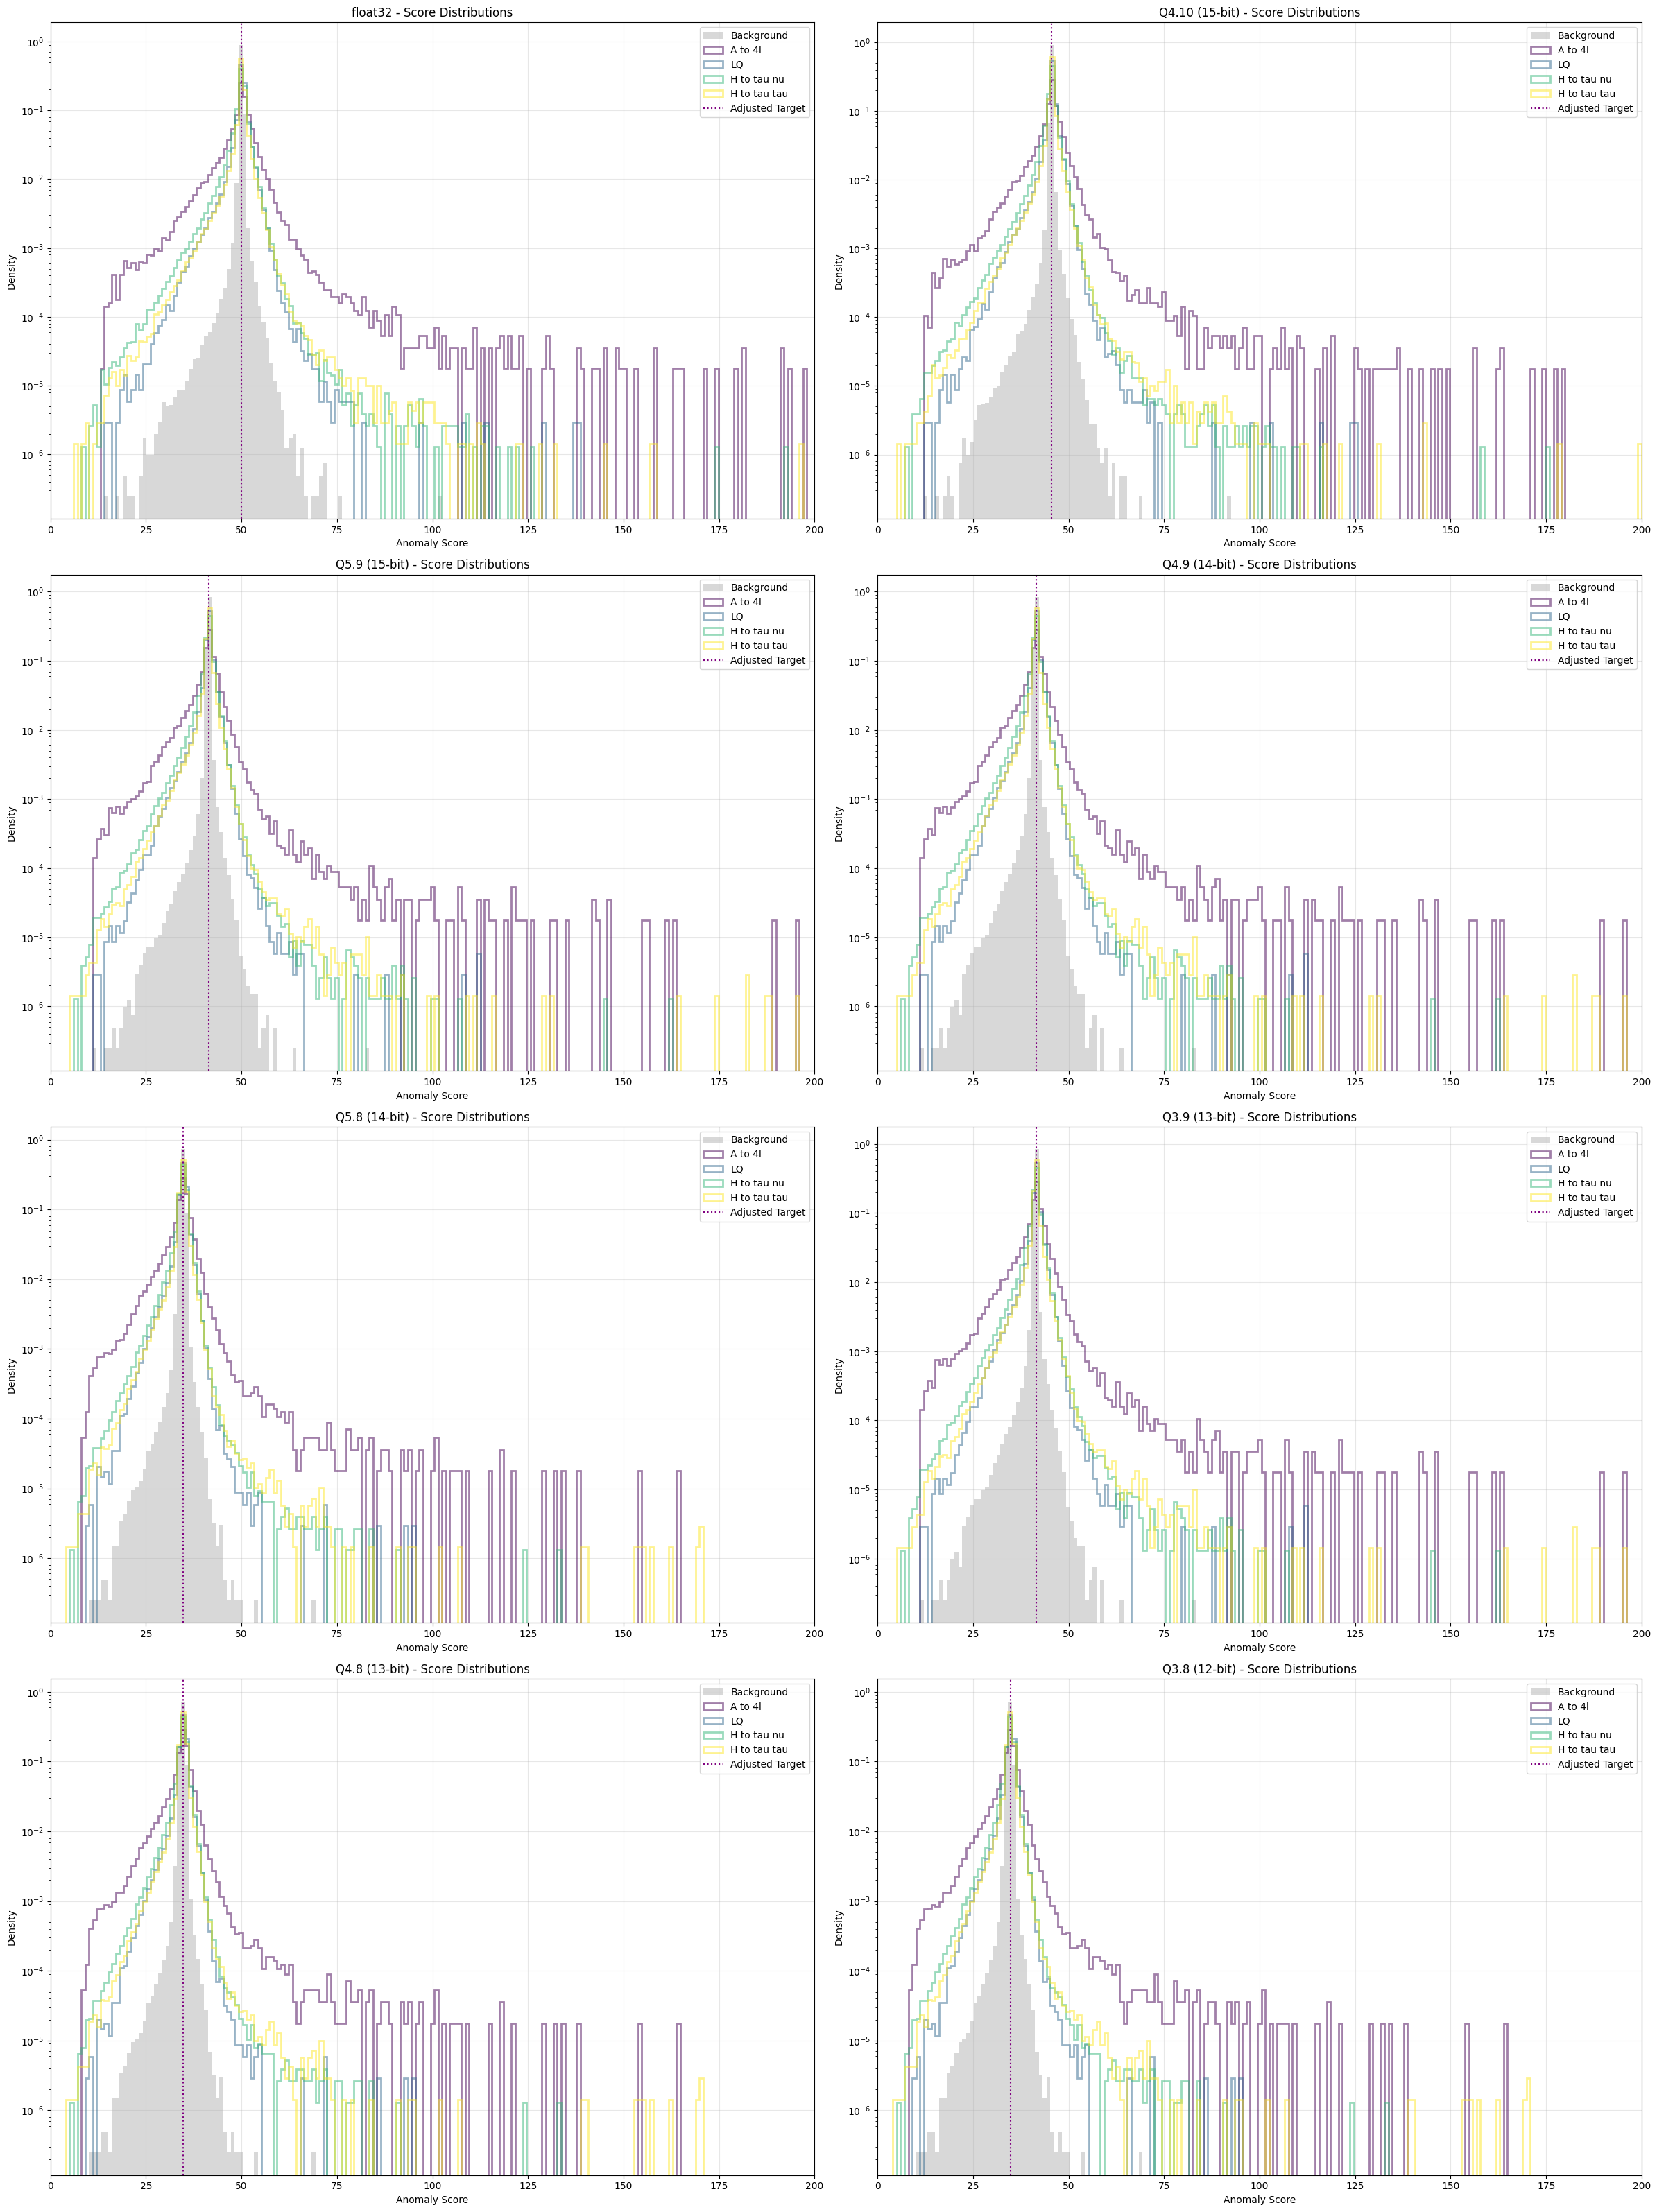

In [ ]:
targets_adjusted = {
    'float32': 50.0,
    'Q5.12 (18-bit)': 48.85,
    'Q5.11 (17-bit)': 47.75,
    'Q4.11 (16-bit)': 47.75,
    'Q5.10 (16-bit)': 45.5,
    'Q7.8 (16-bit)': 34.5,
    'Q5.9 (15-bit)': 41.44,
    'Q4.10 (15-bit)': 45.56,
    'Q4.9 (14-bit)': 41.44,
    'Q5.8 (14-bit)': 34.74,
    'Q4.8 (13-bit)': 34.74,
    'Q3.9 (13-bit)': 41.44,
    'Q3.8 (12-bit)': 34.74,
    'Q2.9 (12-bit)': 41.44,
    'Q5.6 (12-bit)': 10.5,
    'Q3.4 (8-bit)': 0.05,
    'Q1.9 (11-bit)': 40.24,
    'Q0.9 (10-bit)': 23.60,
}

# Plot distributions for each precision
n_configs = len(all_norms)
n_signals = len(signal_loaders)

import math
fig, axes = plt.subplots(math.ceil(n_configs/2), 2, figsize=(24, 4*n_configs))
if n_configs == 1:
    axes = [axes]

colors = plt.cm.viridis(np.linspace(0, 1, n_signals))
xmin = 0
xmax = 200
bins = np.linspace(xmin, xmax, xmax-xmin)

for config_idx, (config_name, results) in enumerate(all_norms.items()):
    ax = axes[int(config_idx/2)][config_idx%2]

    # Plot background
    bkg_scores = results['background']
    ax.hist(bkg_scores, bins=bins, alpha=0.3, label='Background', 
            density=True, histtype='stepfilled', color='gray')
    
    # Plot signals for each config
    for sig_idx, signal_name in enumerate(signal_loaders.keys()):
        sig_scores = results['signals'][signal_name]
        ax.hist(sig_scores, bins=bins, alpha=0.5, label=f'{signal_name}',
                density=True, histtype='step', linewidth=2, color=colors[sig_idx])
        
    ax.axvline(targets_adjusted[config_name], color='purple', linestyle=':', label='Adjusted Target')

    ax.set_xlabel('Anomaly Score')
    ax.set_ylabel('Density')
    ax.set_title(f'{config_name} - Score Distributions')
    ax.legend(loc='best')
    ax.set_yscale('log')
    ax.grid(alpha=0.3)
    ax.set_xlim([xmin, xmax])

plt.tight_layout()
plt.savefig(output_dir+"/norm_distributions_byprecision.png")
plt.show()

In [16]:
# Also print medians to help set targets
print("\nMedian background norms for mixed precision:")
for config_name, results in mixed_results.items():
    median_val = np.median(results['background'])
    print(f"  {config_name}: {median_val:.2f}")


Median background norms for mixed precision:
  Q3.9→Q4.9: 41.44
  Q4.8→Q4.9: 35.84
  Q3.8→Q4.9: 35.84


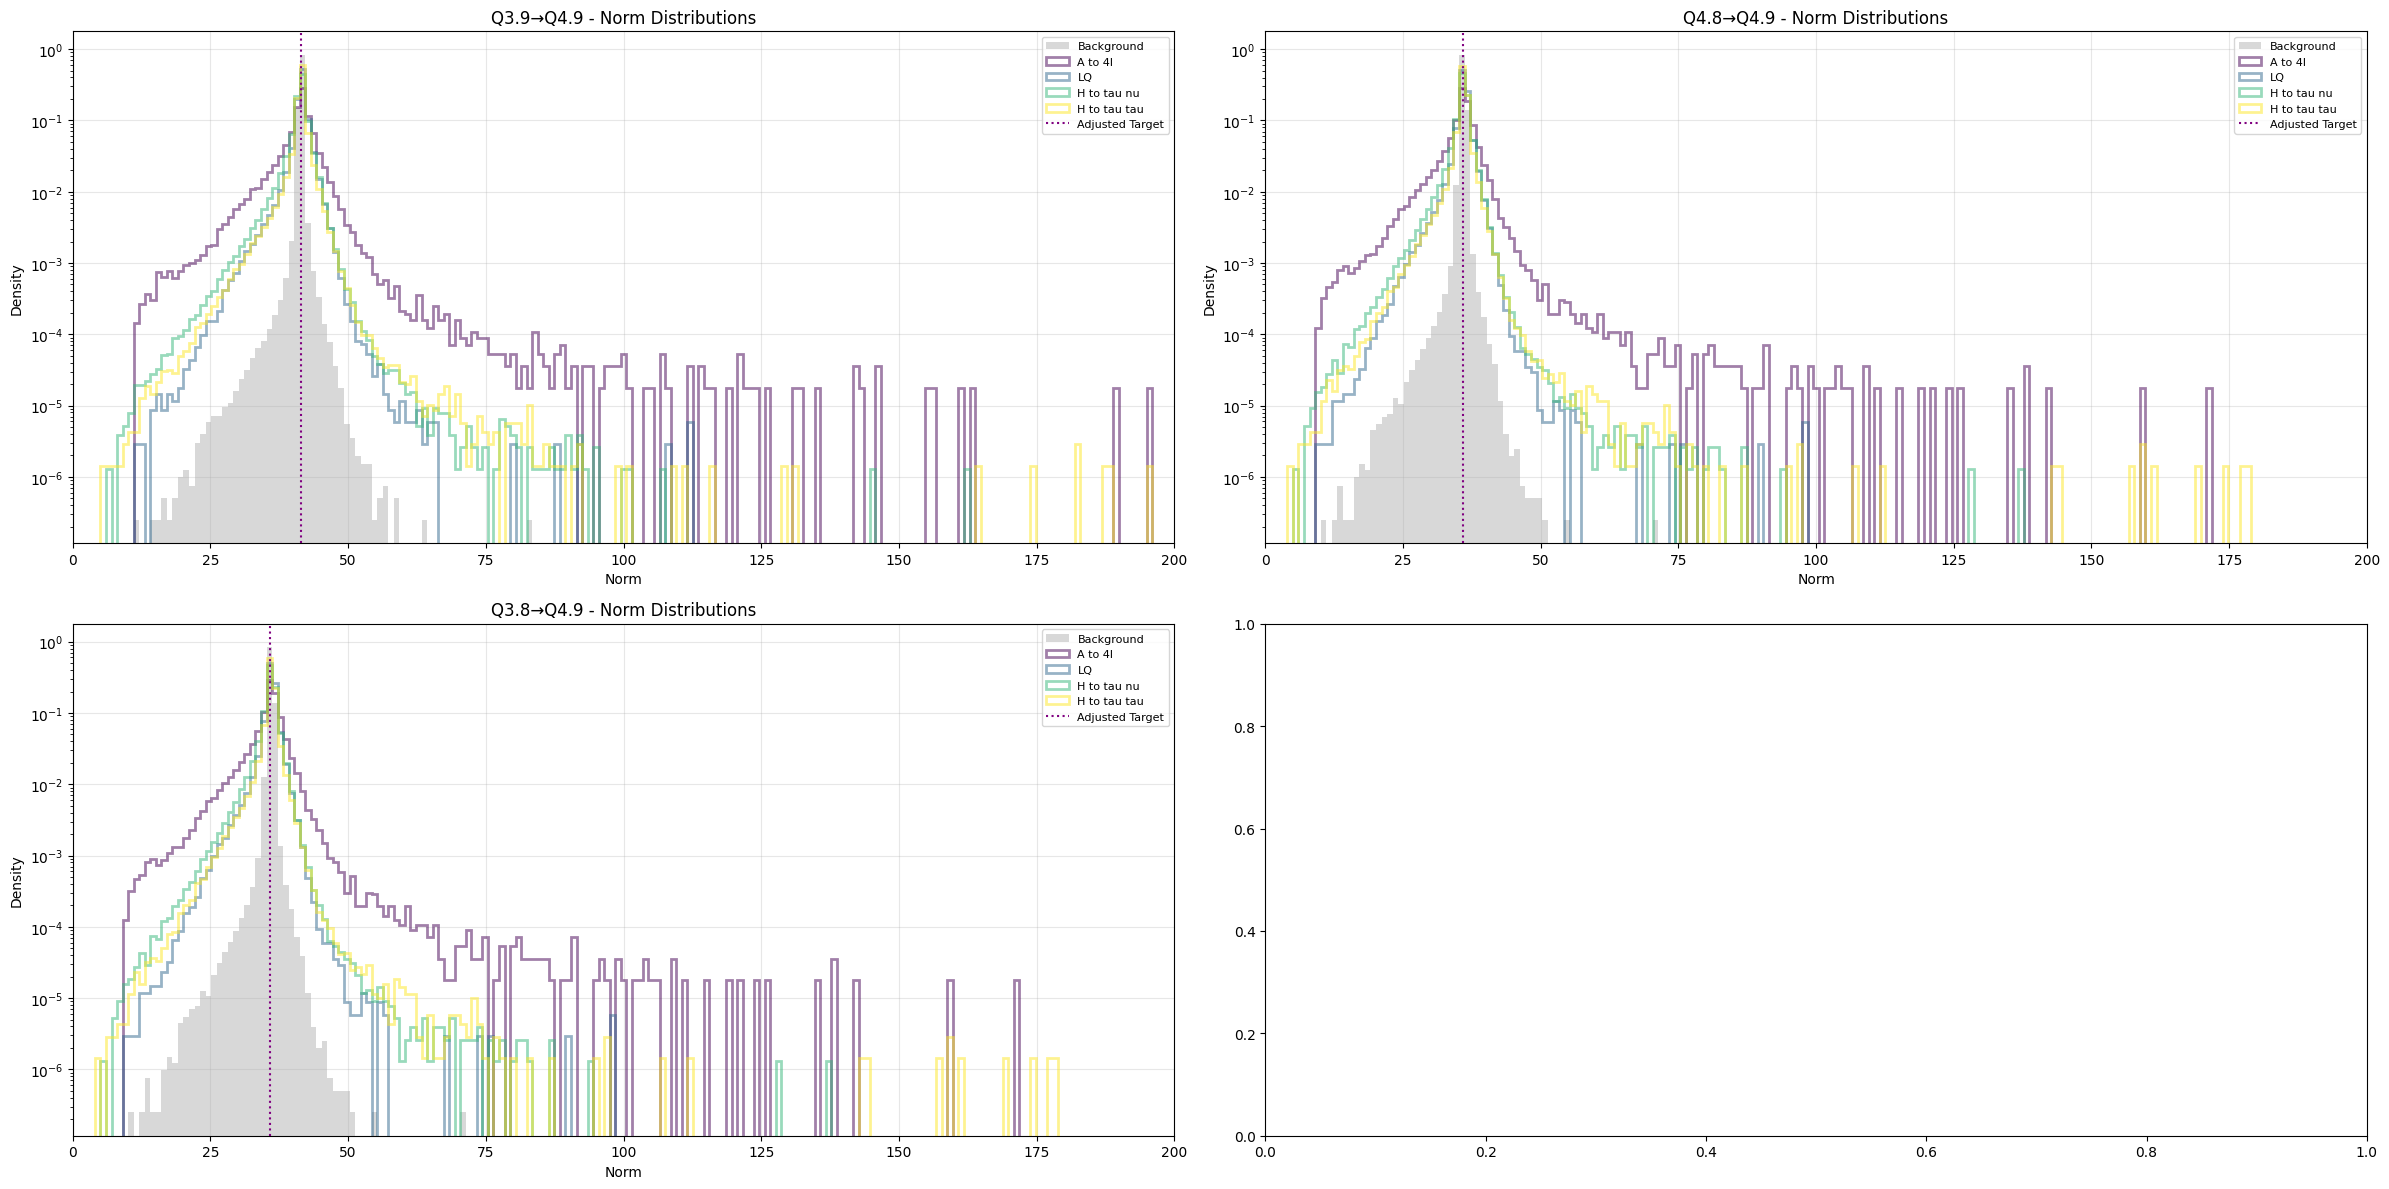

In [18]:
# Define adjusted targets for mixed precision configs
mixed_targets = {
    '18→16': 45.0,
    '18→12': 32.0,
    '16→12': 24.0,
    '16→8':  4.0,
    '15→16': 42.6,
    '14→16': 42.6,
    '16→17': 46.0,
    '13→16': 36.85,
    'Q3.9→Q4.9': 41.44,
    'Q4.8→Q4.9': 35.84,
    'Q3.8→Q4.9': 35.84,

}

# Plot distributions for each mixed precision config
n_mixed_configs = len(mixed_results)
n_signals = len(signal_loaders)

fig, axes = plt.subplots(math.ceil(n_mixed_configs/2), 2, figsize=(24, 4*n_mixed_configs))
if n_mixed_configs == 1:
    axes = [[axes]]
elif n_mixed_configs == 2:
    axes = [axes]

colors = plt.cm.viridis(np.linspace(0, 1, n_signals))
xmin = 0
xmax = 200
bins = np.linspace(xmin, xmax, xmax-xmin)

for config_idx, (config_name, results) in enumerate(mixed_results.items()):
    ax = axes[int(config_idx/2)][config_idx%2]

    # Plot background
    bkg_norms = results['background']
    ax.hist(bkg_norms, bins=bins, alpha=0.3, label='Background', 
            density=True, histtype='stepfilled', color='gray')
    
    # Plot signals
    for sig_idx, signal_name in enumerate(signal_loaders.keys()):
        sig_norms = results['signals'][signal_name]
        ax.hist(sig_norms, bins=bins, alpha=0.5, label=f'{signal_name}',
                density=True, histtype='step', linewidth=2, color=colors[sig_idx])
    
    # Mark adjusted target
    if config_name in mixed_targets:
        ax.axvline(mixed_targets[config_name], color='purple', linestyle=':', label='Adjusted Target')

    ax.set_xlabel('Norm')
    ax.set_ylabel('Density')
    
    # Add layer configs to title
    ax.set_title(f'{config_name} - Norm Distributions')
    ax.legend(loc='best', fontsize=8)
    ax.set_yscale('log')
    ax.grid(alpha=0.3)
    ax.set_xlim([xmin, xmax])

plt.tight_layout()
plt.savefig(output_dir+"/norm_distributions_mixed_precision.png", dpi=150)
plt.show()

## 9. Extract Targets Per Quantization

Extract new targets, and calculate anomaly scores accordingly

In [39]:
def norms_to_scores(all_norms, targets):
    """
    Convert stored norms to anomaly scores with precision-specific targets.
    
    Args:
        all_norms: Dict with norm values per config
        targets: Dict mapping config_name -> target value
                 e.g., {'float32': 50.0, 'Q5.12 (18-bit)': 51.0, ...}
    
    Returns:
        all_scores: Dict with anomaly scores per config
    """
    all_scores = {}
    
    for config_name, results in all_norms.items():
        # Get target for this config
        target = targets.get(config_name, 50.0)  # Default to 50.0 if not specified
        
        all_scores[config_name] = {
            'background': np.abs(results['background'] - target),
            'signals': {
                sig_name: np.abs(sig_norms - target)
                for sig_name, sig_norms in results['signals'].items()
            }
        }
        
        # Copy config/stats if present
        if 'config' in results:
            all_scores[config_name]['config'] = results['config']
        if 'stats' in results:
            all_scores[config_name]['stats'] = results['stats']
    
    return all_scores

# targets_adjusted = {config: 50.0 for config in all_norms.keys()}

all_scores = norms_to_scores(all_norms, targets_adjusted)
mixed_scores = norms_to_scores(mixed_results, mixed_targets)

## 10. Compute Performance Metrics

Calculate AUC and TPR @ FPR=1e-5 for each configuration.

In [40]:
def get_tpr_at_fpr(fpr_array, tpr_array, target_fpr=1e-5):
    """Get TPR at specific FPR value."""
    idx = np.searchsorted(fpr_array, target_fpr, side='right')
    if idx >= len(tpr_array):
        idx = -1
    return tpr_array[idx]

# Compute metrics for all configs and signals
metrics_table = []

for config_name, results in all_scores.items():
    bkg = results['background']
    
    for signal_name, sig in results['signals'].items():
        # Compute ROC
        fpr, tpr = get_roc_curve_data(bkg, sig, anomaly_det=True)
        auc_val = auc(fpr, tpr)
        tpr_at_1e5 = get_tpr_at_fpr(fpr, tpr, target_fpr=1e-5)
        
        metrics_table.append({
            'Config': config_name,
            'Signal': signal_name,
            'AUC': auc_val,
            'TPR@FPR=1e-5': tpr_at_1e5,
        })

# Create DataFrame
df_metrics = pd.DataFrame(metrics_table)

# Pivot for easier comparison
df_auc = df_metrics.pivot(index='Signal', columns='Config', values='AUC')
df_tpr = df_metrics.pivot(index='Signal', columns='Config', values='TPR@FPR=1e-5')

print("\n" + "="*80)
print("AUC COMPARISON")
print("="*80)
print(df_auc.to_string())

print("\n" + "="*80)
print("TPR @ FPR=1e-5 COMPARISON")
print("="*80)
print(df_tpr.to_string())

# Calculate degradation relative to float32
print("\n" + "="*80)
print("AUC DEGRADATION (vs Float32)")
print("="*80)
df_auc_deg = df_auc.subtract(df_auc['float32'], axis=0)
print(df_auc_deg.to_string())

print("\n" + "="*80)
print("TPR DEGRADATION (vs Float32)")
print("="*80)
df_tpr_deg = df_tpr.subtract(df_tpr['float32'], axis=0)
print(df_tpr_deg.to_string())


AUC COMPARISON
Config        Q4.11 (16-bit)  Q4.8 (13-bit)  Q4.9 (14-bit)  Q5.11 (17-bit)  Q5.12 (18-bit)  Q5.9 (15-bit)   float32
Signal                                                                                                             
A to 4l             0.891007       0.809250       0.877699        0.891007        0.891223       0.877699  0.890695
H to tau nu         0.822883       0.703527       0.797577        0.822883        0.823651       0.797577  0.824161
H to tau tau        0.730790       0.656406       0.708970        0.730790        0.728679       0.708970  0.727152
LQ                  0.790072       0.688533       0.762018        0.790072        0.790559       0.762018  0.790089

TPR @ FPR=1e-5 COMPARISON
Config        Q4.11 (16-bit)  Q4.8 (13-bit)  Q4.9 (14-bit)  Q5.11 (17-bit)  Q5.12 (18-bit)  Q5.9 (15-bit)   float32
Signal                                                                                                             
A to 4l             0.012578 

In [41]:
# Compute metrics for mixed precision (same code!)
mixed_metrics_table = []

for config_name, results in mixed_scores.items():
    bkg = results['background']
    
    for signal_name, sig in results['signals'].items():
        # Compute ROC
        fpr, tpr = get_roc_curve_data(bkg, sig, anomaly_det=True)
        auc_val = auc(fpr, tpr)
        tpr_at_1e5 = get_tpr_at_fpr(fpr, tpr, target_fpr=1e-5)
        
        mixed_metrics_table.append({
            'Config': config_name,
            'Signal': signal_name,
            'AUC': auc_val,
            'TPR@FPR=1e-5': tpr_at_1e5,
        })

# Create DataFrame
df_mixed_metrics = pd.DataFrame(mixed_metrics_table)
df_mixed_auc = df_mixed_metrics.pivot(index='Signal', columns='Config', values='AUC')
df_mixed_tpr = df_mixed_metrics.pivot(index='Signal', columns='Config', values='TPR@FPR=1e-5')

print("\n" + "="*80)
print("MIXED PRECISION - AUC COMPARISON")
print("="*80)
print(df_mixed_auc.to_string())

print("\n" + "="*80)
print("MIXED PRECISION - TPR @ FPR=1e-5 COMPARISON")
print("="*80)
print(df_mixed_tpr.to_string())

# Compare best mixed vs uniform configs
print("\n" + "="*80)
print("MIXED vs UNIFORM (Side-by-side)")
print("="*80)
# Combine the two dataframes
df_combined_auc = pd.concat([
    df_auc[['float32', 'Q5.12 (18-bit)', 'Q5.9 (15-bit)', 'Q4.9 (14-bit)', 'Q4.8 (13-bit)']],
    df_mixed_auc
], axis=1)
print(df_combined_auc.to_string())


MIXED PRECISION - AUC COMPARISON
Config           13→16     14→16     15→16     16→17
Signal                                              
A to 4l       0.857971  0.885623  0.885623  0.885850
H to tau nu   0.766059  0.815415  0.815415  0.814737
H to tau tau  0.692494  0.720766  0.720766  0.715804
LQ            0.740856  0.781205  0.781205  0.781169

MIXED PRECISION - TPR @ FPR=1e-5 COMPARISON
Config           13→16     14→16     15→16     16→17
Signal                                              
A to 4l       0.012275  0.012400  0.012400  0.012596
H to tau nu   0.001119  0.001161  0.001161  0.001202
H to tau tau  0.000775  0.000797  0.000797  0.000833
LQ            0.000335  0.000335  0.000335  0.000332

MIXED vs UNIFORM (Side-by-side)
Config         float32  Q5.12 (18-bit)  Q5.9 (15-bit)  Q4.9 (14-bit)  Q4.8 (13-bit)     13→16     14→16     15→16     16→17
Signal                                                                                                                     
A to

## 11. Plot Score Distributions

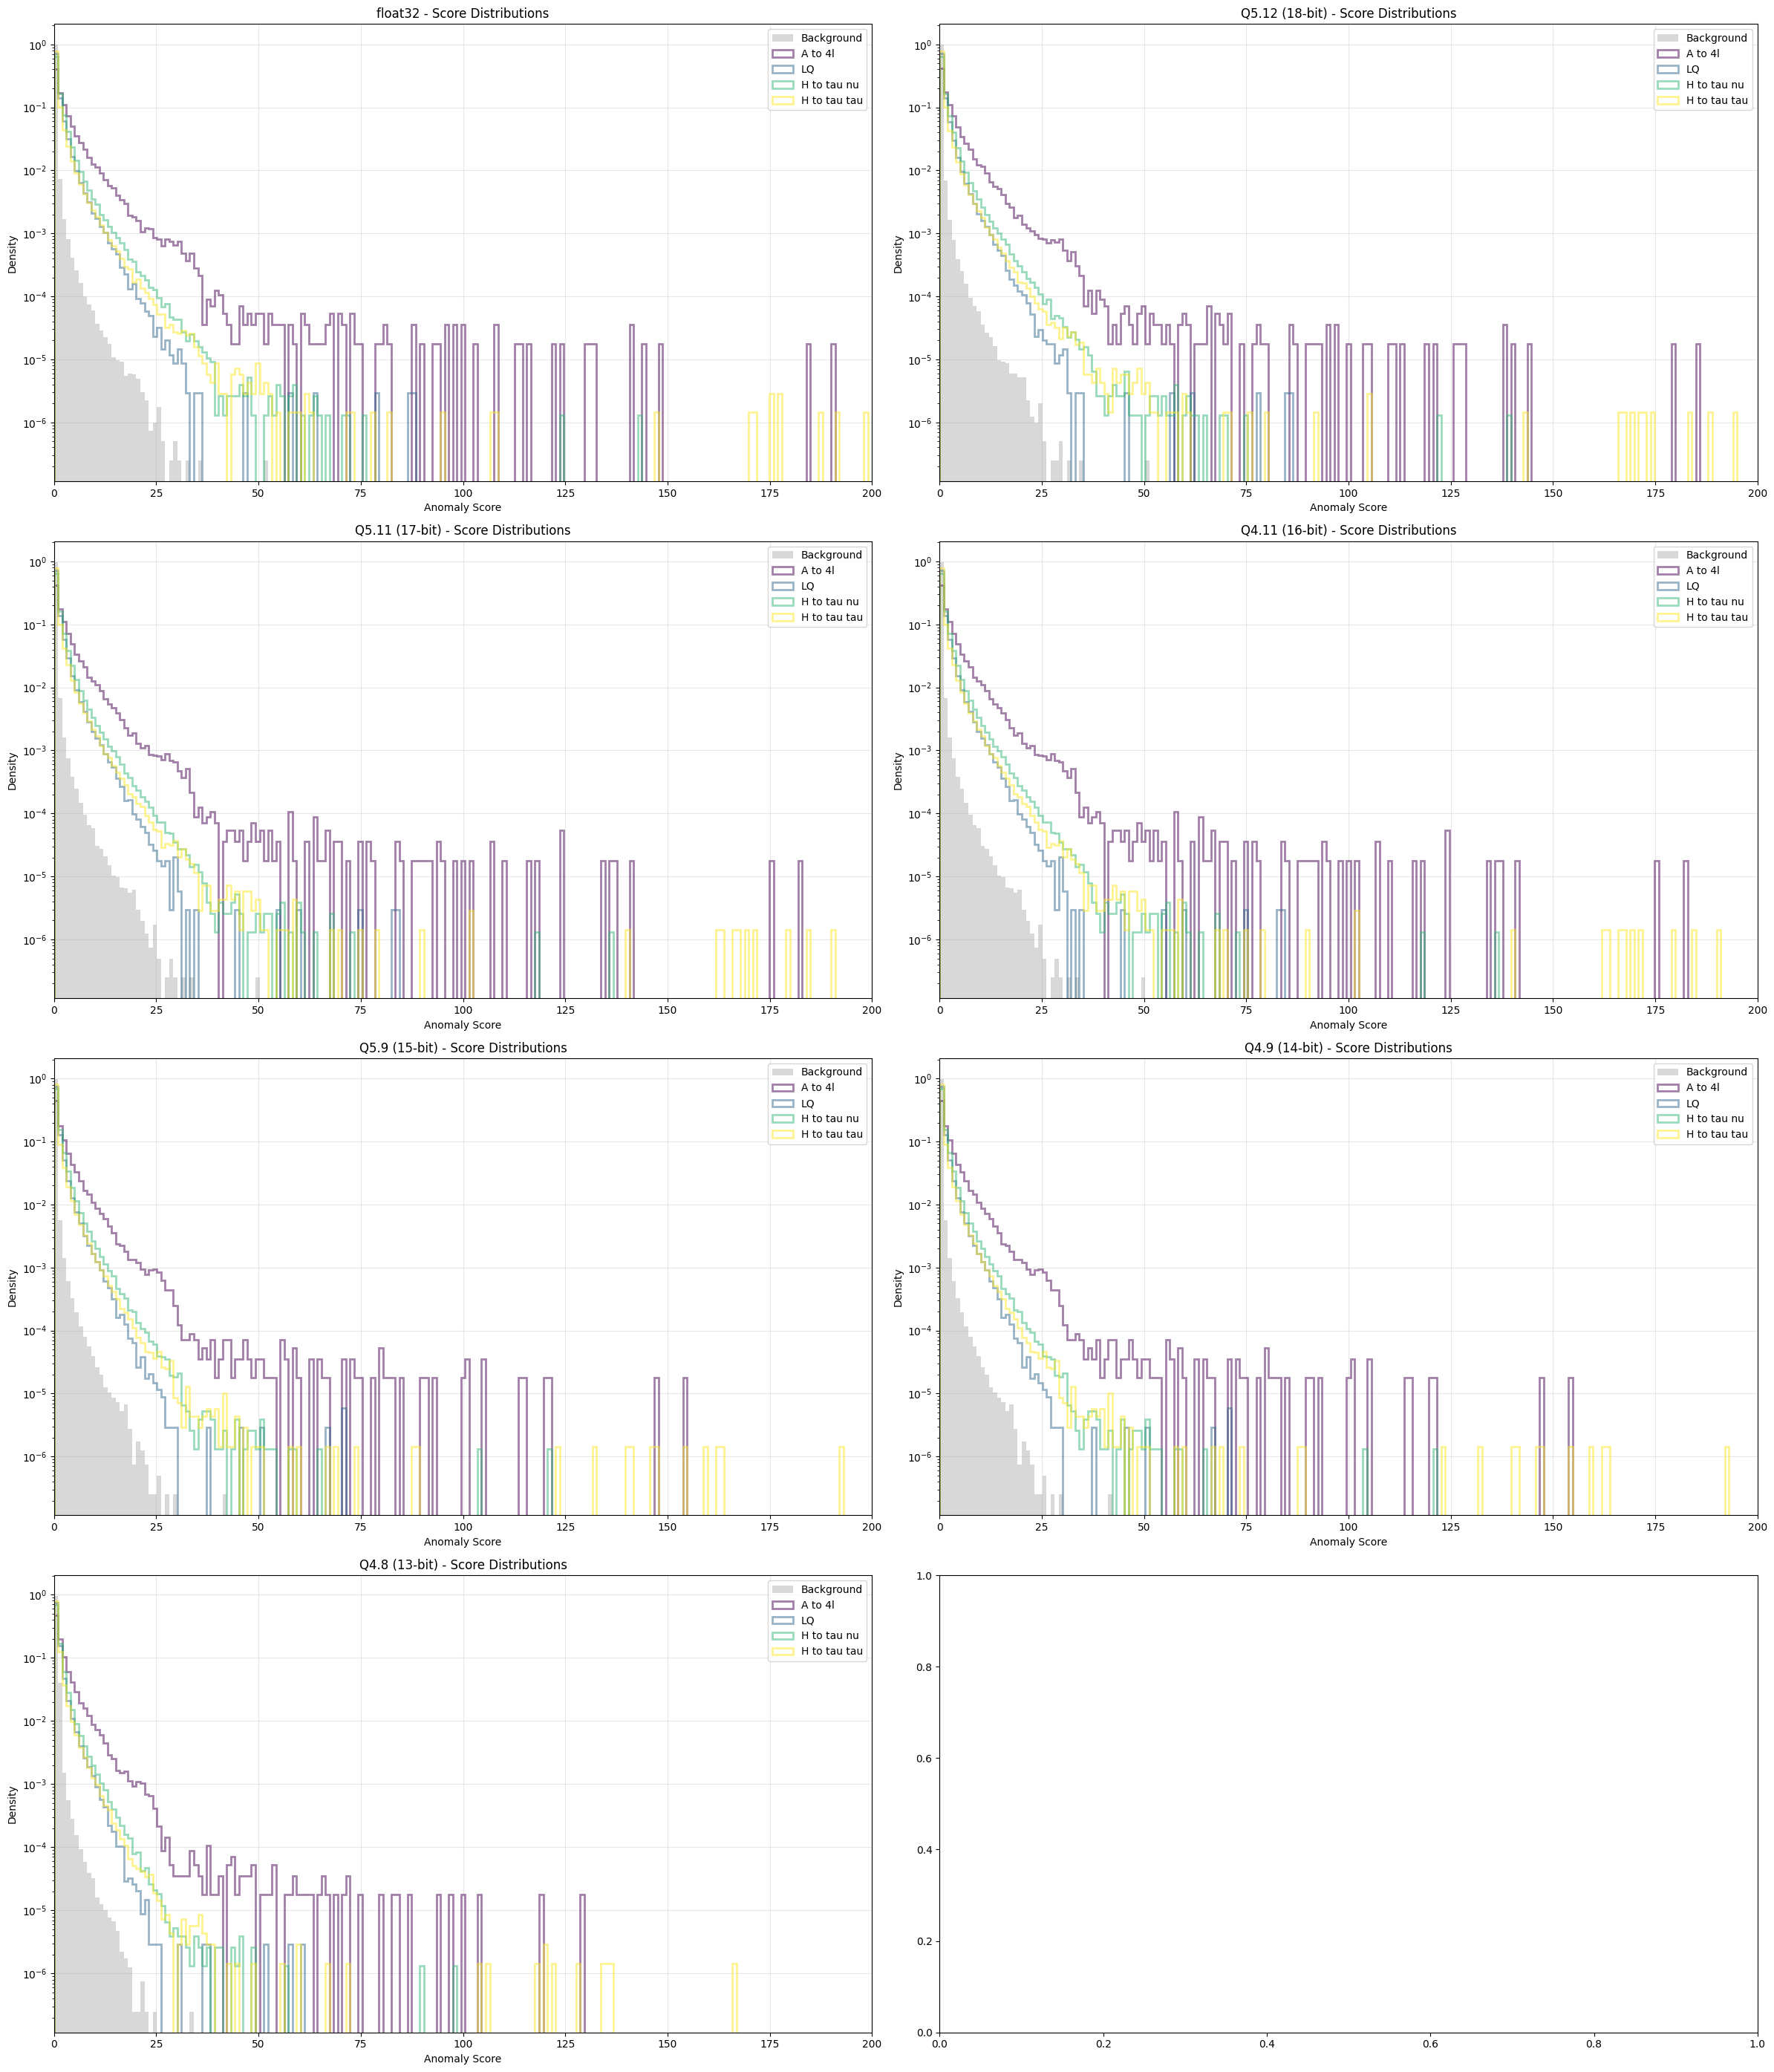

In [42]:
# Plot distributions for each precision
n_configs = len(all_scores)
n_signals = len(signal_loaders)

import math
fig, axes = plt.subplots(math.ceil(n_configs/2), 2, figsize=(24, 4*n_configs))
if n_configs == 1:
    axes = [axes]

colors = plt.cm.viridis(np.linspace(0, 1, n_signals))
xmin = 0
xmax = 200
bins = np.linspace(xmin, xmax, xmax-xmin)

for config_idx, (config_name, results) in enumerate(all_scores.items()):
    ax = axes[int(config_idx/2)][config_idx%2]

    # Plot background
    bkg_scores = results['background']
    ax.hist(bkg_scores, bins=bins, alpha=0.3, label='Background', 
            density=True, histtype='stepfilled', color='gray')
    
    # Plot signals for each config
    for sig_idx, signal_name in enumerate(signal_loaders.keys()):
        sig_scores = results['signals'][signal_name]
        ax.hist(sig_scores, bins=bins, alpha=0.5, label=f'{signal_name}',
                density=True, histtype='step', linewidth=2, color=colors[sig_idx])

    ax.set_xlabel('Anomaly Score')
    ax.set_ylabel('Density')
    ax.set_title(f'{config_name} - Score Distributions')
    ax.legend(loc='best')
    ax.set_yscale('log')
    ax.grid(alpha=0.3)
    ax.set_xlim([xmin, xmax])

plt.tight_layout()
plt.savefig(output_dir+"/anomaly_score_distributions_byprecision.png")
plt.show()

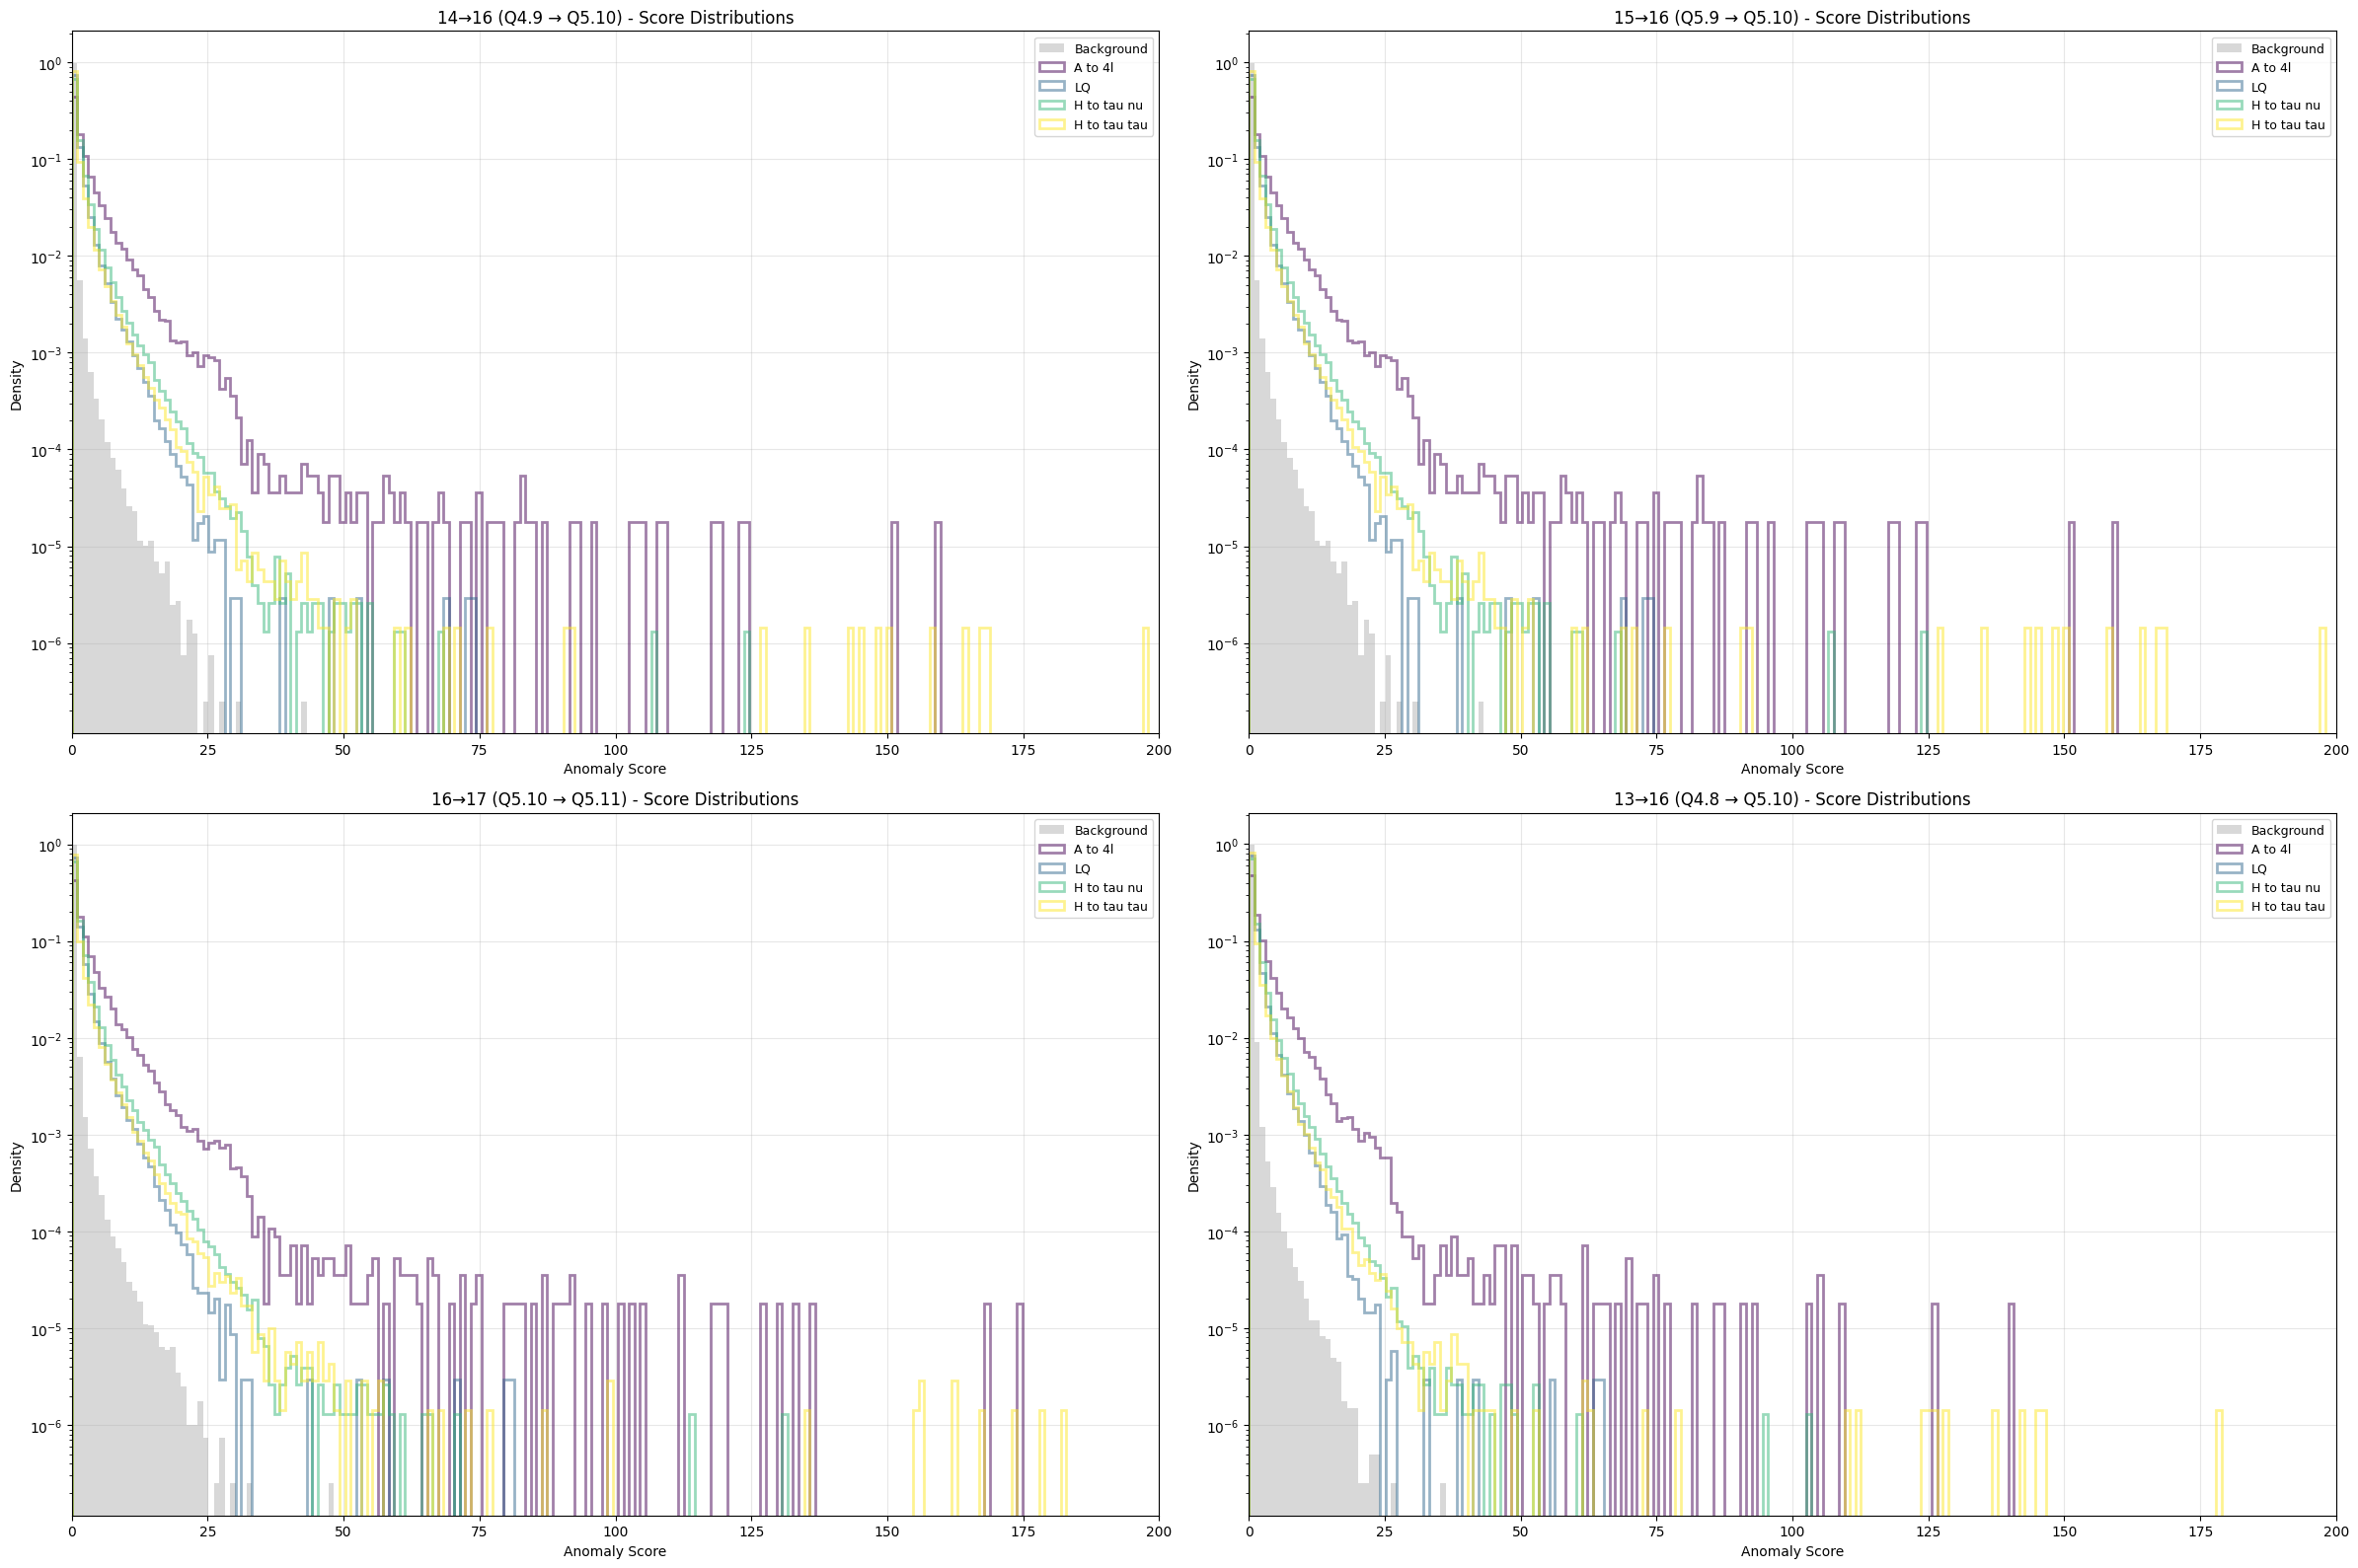

In [43]:
# Plot distributions for each mixed precision config
n_mixed_configs = len(mixed_scores)
n_signals = len(signal_loaders)

fig, axes = plt.subplots(math.ceil(n_mixed_configs/2), 2, figsize=(24, 4*n_mixed_configs))
if n_mixed_configs == 1:
    axes = [[axes]]
elif n_mixed_configs == 2:
    axes = [axes]

colors = plt.cm.viridis(np.linspace(0, 1, n_signals))
xmin = 0
xmax = 200
bins = np.linspace(xmin, xmax, xmax-xmin)

for config_idx, (config_name, results) in enumerate(mixed_scores.items()):
    ax = axes[int(config_idx/2)][config_idx%2]

    # Plot background
    bkg_scores = results['background']
    ax.hist(bkg_scores, bins=bins, alpha=0.3, label='Background', 
            density=True, histtype='stepfilled', color='gray')
    
    # Plot signals
    for sig_idx, signal_name in enumerate(signal_loaders.keys()):
        sig_scores = results['signals'][signal_name]
        ax.hist(sig_scores, bins=bins, alpha=0.5, label=f'{signal_name}',
                density=True, histtype='step', linewidth=2, color=colors[sig_idx])

    # Add layer configs to title for context
    if config_name in mixed_results and 'configs' in mixed_results[config_name]:
        layer_info = " → ".join([str(c) for c in mixed_results[config_name]['configs']])
        title = f'{config_name} ({layer_info}) - Score Distributions'
    else:
        title = f'{config_name} - Score Distributions'
    
    ax.set_xlabel('Anomaly Score')
    ax.set_ylabel('Density')
    ax.set_title(title)
    ax.legend(loc='best', fontsize=9)
    ax.set_yscale('log')
    ax.grid(alpha=0.3)
    ax.set_xlim([xmin, xmax])

plt.tight_layout()
plt.savefig(output_dir+"/anomaly_score_distributions_mixed_precision.png", dpi=150)
plt.show()

## 12. Plot ROC Curves

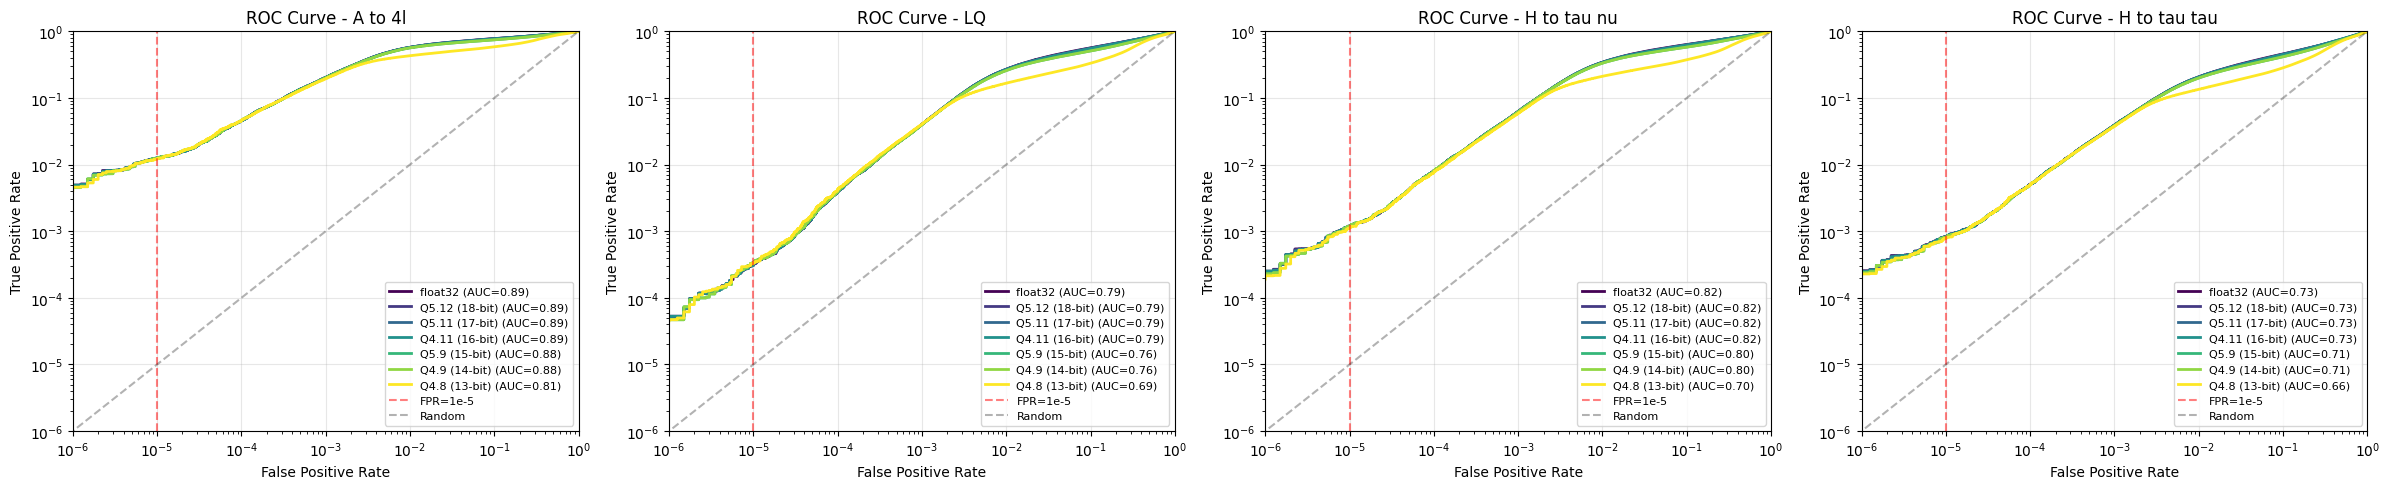

In [48]:
# Plot ROC curves for each signal
colors = plt.cm.viridis(np.linspace(0, 1, len(all_scores)))

fig, axes = plt.subplots(1, n_signals, figsize=(6*n_signals, 5))
if n_signals == 1:
    axes = [axes]

for sig_idx, signal_name in enumerate(signal_loaders.keys()):
    ax = axes[sig_idx]
    
    # Plot ROC for each config
    for config_idx, (config_name, results) in enumerate(all_scores.items()):
        bkg = results['background']
        sig = results['signals'][signal_name]
        
        fpr, tpr = get_roc_curve_data(bkg, sig, anomaly_det=True)
        auc_val = auc(fpr, tpr)
        
        ax.plot(fpr, tpr, label=f'{config_name} (AUC={auc_val:.2f})',
                linewidth=2, color=colors[config_idx])
    
    # Add FPR = 1e-5 line
    ax.axvline(x=1e-5, color='red', linestyle='--', alpha=0.5, label='FPR=1e-5')
    
    # Diagonal reference
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve - {signal_name}')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_xlim([1e-6, 1])
    ax.set_ylim([1e-6, 1])

plt.tight_layout()
plt.savefig(output_dir+"/roc_curves.png")
plt.show()

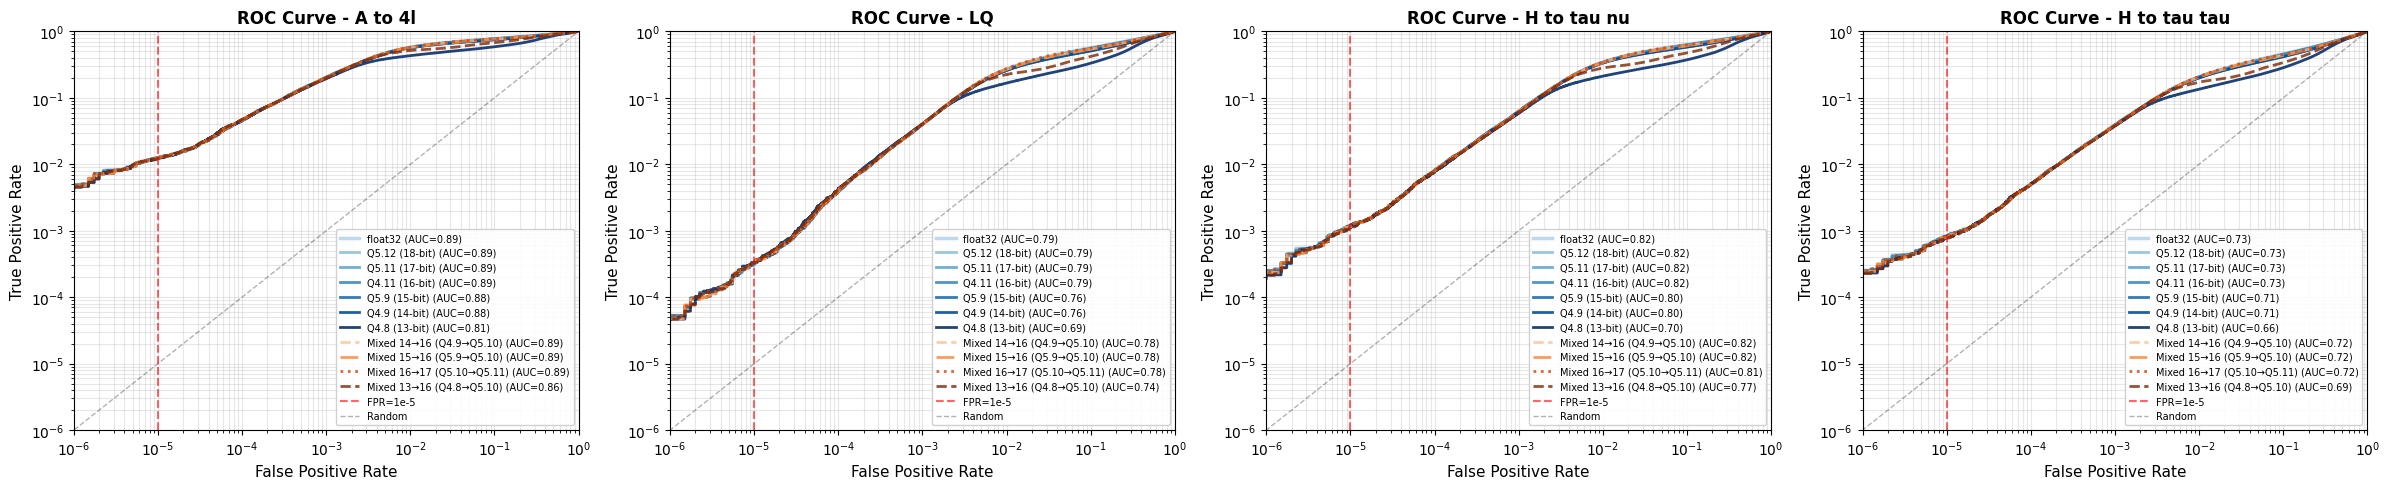

In [49]:
# Plot ROC curves for each signal - combining uniform and mixed precision
fig, axes = plt.subplots(1, n_signals, figsize=(6*n_signals, 5))
if n_signals == 1:
    axes = [axes]

# Define colors and linestyles
uniform_colors = plt.cm.Blues(np.linspace(0.3, 1.0, len(all_scores)))
mixed_colors = plt.cm.Oranges(np.linspace(0.3, 1.0, len(mixed_scores)))
linestyles_uniform = ['-', '-', '-', '-', '-', '-', '-']  # Solid for uniform
linestyles_mixed = ['--', '-.', ':', '--', '-.']  # Varied for mixed

for sig_idx, signal_name in enumerate(signal_loaders.keys()):
    ax = axes[sig_idx]
    
    # Plot uniform precision configs
    for config_idx, (config_name, results) in enumerate(all_scores.items()):
        bkg = results['background']
        sig = results['signals'][signal_name]
        
        fpr, tpr = get_roc_curve_data(bkg, sig, anomaly_det=True)
        auc_val = auc(fpr, tpr)
        
        ax.plot(fpr, tpr, 
                label=f'{config_name} (AUC={auc_val:.2f})',
                linewidth=2.5 if config_name == 'float32' else 2,
                color=uniform_colors[config_idx],
                linestyle=linestyles_uniform[config_idx],
                alpha=0.9)
    
    # Plot mixed precision configs
    for config_idx, (config_name, results) in enumerate(mixed_scores.items()):
        bkg = results['background']
        sig = results['signals'][signal_name]
        
        fpr, tpr = get_roc_curve_data(bkg, sig, anomaly_det=True)
        auc_val = auc(fpr, tpr)
        
        # Add layer info to label
        if config_name in mixed_results and 'configs' in mixed_results[config_name]:
            layer_info = "→".join([str(c) for c in mixed_results[config_name]['configs']])
            label_text = f'Mixed {config_name} ({layer_info}) (AUC={auc_val:.2f})'
        else:
            label_text = f'Mixed {config_name} (AUC={auc_val:.2f})'
        
        ax.plot(fpr, tpr, 
                label=label_text,
                linewidth=2,
                color=mixed_colors[config_idx],
                linestyle=linestyles_mixed[config_idx],
                alpha=0.8)
    
    # Add FPR = 1e-5 line
    ax.axvline(x=1e-5, color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='FPR=1e-5')
    
    # Diagonal reference
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=1, label='Random')
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(f'ROC Curve - {signal_name}', fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=7, framealpha=0.9)
    ax.grid(alpha=0.3, which='both')
    ax.set_xlim([1e-6, 1])
    ax.set_ylim([1e-6, 1])

plt.tight_layout()
plt.savefig(output_dir+"/roc_curves_unified.png", dpi=200)
plt.show()

## 13. Summary: AUC vs Bit-Width

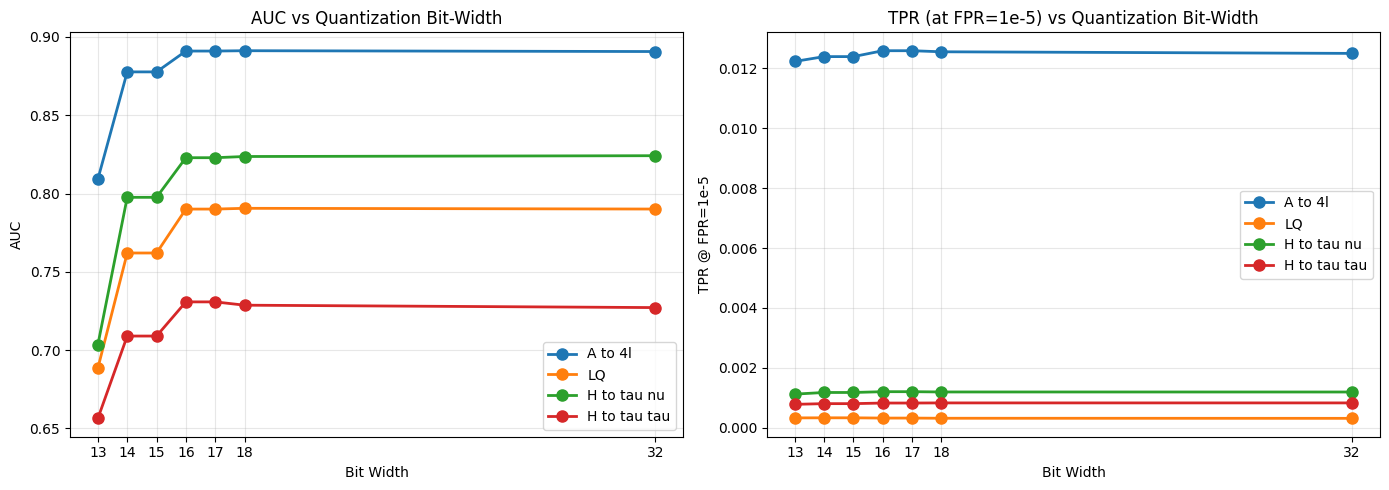

In [50]:
# Extract bit-widths for plotting
bit_widths = [32]  # float32
for n_word, n_frac, name in quantization_configs:
    bit_widths.append(n_word)

# Plot AUC vs bit-width for each signal
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# AUC plot
for signal_name in signal_loaders.keys():
    aucs = []
    for config_name in all_scores.keys():
        bkg = all_scores[config_name]['background']
        sig = all_scores[config_name]['signals'][signal_name]
        fpr, tpr = get_roc_curve_data(bkg, sig, anomaly_det=True)
        aucs.append(auc(fpr, tpr))
    
    ax1.plot(bit_widths, aucs, marker='o', linewidth=2, markersize=8, label=signal_name)

ax1.set_xlabel('Bit Width')
ax1.set_ylabel('AUC')
ax1.set_title('AUC vs Quantization Bit-Width')
ax1.legend()
ax1.grid(alpha=0.3)
ax1.set_xticks(bit_widths)

# TPR@1e-5 plot
for signal_name in signal_loaders.keys():
    tprs = []
    for config_name in all_scores.keys():
        bkg = all_scores[config_name]['background']
        sig = all_scores[config_name]['signals'][signal_name]
        fpr, tpr = get_roc_curve_data(bkg, sig, anomaly_det=True)
        tprs.append(get_tpr_at_fpr(fpr, tpr, target_fpr=1e-5))
    
    ax2.plot(bit_widths, tprs, marker='o', linewidth=2, markersize=8, label=signal_name)

ax2.set_xlabel('Bit Width')
ax2.set_ylabel('TPR @ FPR=1e-5')
ax2.set_title('TPR (at FPR=1e-5) vs Quantization Bit-Width')
ax2.legend()
ax2.grid(alpha=0.3)
ax2.set_xticks(bit_widths)

plt.tight_layout()
plt.savefig(output_dir+"/auc_vs_quantization.png")
plt.show()

## 14. Save Results

In [51]:
# Save metrics table
df_metrics.to_csv(os.path.join(output_dir, 'quantization_metrics.csv'), index=False)
df_auc_deg.to_csv(os.path.join(output_dir, 'auc_degradation.csv'))
df_tpr_deg.to_csv(os.path.join(output_dir, 'tpr_degradation.csv'))

df_mixed_metrics.to_csv(os.path.join(output_dir, 'quantization_metrics_mixed.csv'), index=False)
df_mixed_auc.to_csv(os.path.join(output_dir, 'auc_degradation_mixed.csv'))
df_mixed_tpr.to_csv(os.path.join(output_dir, 'tpr_degradation_mixed.csv'))
print(f"✅ Results saved to {output_dir}")

✅ Results saved to ../output/Huber_AE_Results_bd8_3//quantization_results
